In [61]:
# Elige aquí la zona que quieres pintar:
# "global", "chopper", "collimators", "triplet", "solenoid", "final_section"
plot_region = "global"

# ============================================================
# Límites de plot
# ============================================================

plot_windows = {
    # Toda la sección activa: drift3 -> drift10
    "global": (0.0, 3.4),

    # Chopper: 0.208 -> 0.358 m
    # Margen amplio para verlo cómodo
    "chopper": (0.0, 0.48),

    # Colimadores: collx 1.220 -> 1.222,
    # drift_col 1.222 -> 1.224,
    # colly 1.224 -> 1.226 m
    "collimators": (1.17, 1.27),

    # Triplete completo:
    # drift6 + quad1 + drift7 + quad2 + drift8 + quad3
    # aprox. 1.226 -> 2.020 m
    "triplet": (1.3, 2.12),

    # Solo zona de cuadrupolos, más cerrada
    "quads": (1.4, 1.6),

    # Solenoide:
    # sol 2.9341 -> 3.1915 m
    "solenoid": (2.78, 3.4),

    # Última sección: drift9 + solenoide + drift10
    "final_section": (2.55, 3.3305),
}

s_min_plot, s_max_plot = plot_windows[plot_region]
xlim_plot = (s_min_plot, s_max_plot)

In [62]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from IPython.display import display

# ============================================================
# Sufijo global para benchmark con space charge
# ============================================================


# =========================
# Plot style for thesis figures
# =========================

FIG_WIDTH = 7.0      # inches
FIG_HEIGHT = 4.0     # inches

FONT_SIZE = 11       # igual que texto del documento si usas 11 pt
LABEL_SIZE = 12
TICK_SIZE = 11
LEGEND_SIZE = 10
TITLE_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "figure.titlesize": TITLE_SIZE,
    "lines.linewidth": 2.0,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "savefig.dpi": 300,
    "figure.dpi": 120,
})

root = Path.cwd()

# Constants and parameters
m_c12_6 = 11.9967074084982  # amu
amu = 931.49410372          # MeV/c^2
mass = m_c12_6 * amu        # MeV/c^2

OUTPUT_SUFFIX = "_sc"


def add_output_suffix(filename, suffix=OUTPUT_SUFFIX):
    """
    Añade el sufijo _sc antes de la extensión.

    Ejemplos:
        sigma_x_evolution.pdf -> sigma_x_evolution_sc.pdf
        sigma_x_evolution_sc.pdf -> sigma_x_evolution_sc.pdf
    """
    path = Path(filename)

    if path.stem.endswith(suffix):
        return str(path)

    if path.suffix:
        return str(path.with_name(path.stem + suffix + path.suffix))

    return str(path.with_name(path.name + suffix))


# ============================================================
# Helpers robustos
# ============================================================

def to_1d_array(x):
    return np.atleast_1d(np.asarray(x, dtype=float)).ravel()


def make_curve_compatible(s, y):
    s = to_1d_array(s)
    y = to_1d_array(y)

    if len(y) == 1 and len(s) > 1:
        y = np.full_like(s, y[0], dtype=float)

    if len(s) == 1 and len(y) > 1:
        s = np.full_like(y, s[0], dtype=float)

    n = min(len(s), len(y))
    return s[:n], y[:n]


def cut_to_xlim(s, y, x_min=None, x_max=None):
    """
    Recorta los arrays s e y al rango [x_min, x_max] y elimina NaN/inf.
    """
    s, y = make_curve_compatible(s, y)

    if x_min is None:
        x_min = globals().get("s_min_plot", -np.inf)

    if x_max is None:
        x_max = globals().get("s_max_plot", np.inf)

    mask = (
        np.isfinite(s)
        & np.isfinite(y)
        & (s >= x_min)
        & (s <= x_max)
    )

    return s[mask], y[mask]


# ============================================================
# Estilos de líneas
# ============================================================

DEFAULT_LINEWIDTH = 2.2
RFTRACK_VOLUME_LINEWIDTH = 3.4


def _default_linewidth(label):
    """
    Hace que RF-Track Volume se vea más grueso por defecto.
    """
    if str(label).strip() in ["RF-Track Volume", "RF-Track Vol."]:
        return RFTRACK_VOLUME_LINEWIDTH

    return DEFAULT_LINEWIDTH


def _unpack_curve(curve):
    """
    Acepta curvas en estos formatos:

        (label, s, y, linestyle)
        (label, s, y, linestyle, color)
        (label, s, y, linestyle, color, linewidth)
    """
    if len(curve) == 4:
        label, s, y, linestyle = curve
        color = None
        linewidth = _default_linewidth(label)

    elif len(curve) == 5:
        label, s, y, linestyle, color = curve
        linewidth = _default_linewidth(label)

    elif len(curve) == 6:
        label, s, y, linestyle, color, linewidth = curve

    else:
        raise ValueError(
            "Cada curva debe tener 4, 5 o 6 elementos: "
            "(label, s, y, linestyle), "
            "(label, s, y, linestyle, color) o "
            "(label, s, y, linestyle, color, linewidth)."
        )

    return label, s, y, linestyle, color, linewidth


def _set_auto_ylim(ax, y_values):
    """
    Ajusta automáticamente el eje y usando todos los datos finitos.
    """
    valid_arrays = [
        yy[np.isfinite(yy)]
        for yy in y_values
        if len(yy) > 0
    ]

    if len(valid_arrays) == 0:
        return

    y_all = np.concatenate(valid_arrays)

    if len(y_all) == 0:
        return

    y_min = np.min(y_all)
    y_max = np.max(y_all)

    if np.isclose(y_min, y_max):
        margin = 0.05 * abs(y_max) if y_max != 0 else 1.0
        ax.set_ylim(y_min - margin, y_max + margin)

    elif y_min >= 0:
        ax.set_ylim(0.0, 1.10 * y_max)

    else:
        margin = 0.10 * (y_max - y_min)
        ax.set_ylim(y_min - margin, y_max + margin)


def _get_ylim_key(filename, filename_out):
    """
    Busca límites verticales en ylims probando nombre normal,
    nombre con _sc y basename.
    """
    if "ylims" not in globals():
        return None

    candidates = [
        str(filename),
        str(filename_out),
        Path(filename).name,
        Path(filename_out).name,
    ]

    for key in candidates:
        if key in ylims and ylims[key] is not None:
            return key

    return None


def get_auto_x_limits(curve_groups, s_min=None, pad_frac=0.01):
    """
    Devuelve un xlim que llega hasta el punto más lejano de todos los arrays
    que realmente tienen datos finitos.

    curve_groups puede ser:
    - [curves] para plot_param
    - [curves_top, curves_bottom] para plot_param_double
    """

    if s_min is None:
        s_min = globals().get("s_min_plot", 0.0)

    s_max_values = []

    for curves in curve_groups:
        for curve in curves:
            label, s, y, linestyle, color, linewidth = _unpack_curve(curve)

            s = to_1d_array(s)
            y = to_1d_array(y)

            n = min(len(s), len(y))
            s = s[:n]
            y = y[:n]

            mask = np.isfinite(s) & np.isfinite(y)

            if np.any(mask):
                s_max_values.append(np.max(s[mask]))

    if len(s_max_values) == 0:
        return globals().get("xlim_plot", (s_min, s_min + 1.0))

    s_max = max(s_max_values)

    dx = s_max - s_min
    pad = pad_frac * dx if dx > 0 else 0.01

    return (s_min, s_max + pad)


# ============================================================
# Límites verticales opcionales
# ============================================================

ylims = {
    # PNG antiguos
    "sigma_x_evolution.png": None,
    "sigma_y_evolution.png": None,
    "sigma_xp_evolution.png": None,
    "sigma_yp_evolution.png": None,
    "emit_x_evolution.png": None,
    "emit_y_evolution.png": None,
    "emit4D_evolution.png": None,
    "beta_x_evolution.png": None,
    "beta_y_evolution.png": None,
    "alpha_x_evolution.png": None,
    "alpha_y_evolution.png": None,
    "energy_evolution.png": None,
    "momentum_evolution.png": None,
    "transmission_evolution.png": (80, 101),

    # PDF nuevos sin sufijo
    "sigma_x_evolution.pdf": None,
    "sigma_y_evolution.pdf": None,
    "sigma_xp_evolution.pdf": None,
    "sigma_yp_evolution.pdf": None,
    "energy_evolution.pdf": None,
    "momentum_evolution.pdf": None,
    "transmission_evolution.pdf": (80, 101),

    # PDF nuevos con sufijo _sc
    "sigma_x_evolution_sc.pdf": None,
    "sigma_y_evolution_sc.pdf": None,
    "sigma_xp_evolution_sc.pdf": None,
    "sigma_yp_evolution_sc.pdf": None,
    "energy_evolution_sc.pdf": None,
    "momentum_evolution_sc.pdf": None,
    "transmission_evolution_sc.pdf": (80, 101),
}


# ============================================================
# Guardado robusto de figuras
# ============================================================

def save_figure(fig, filename):
    """
    Guarda la figura en outdir con buena resolución.

    - Si filename es solo un nombre, lo guarda en outdir.
    - Si filename ya incluye carpeta, respeta esa ruta.
    - Evita duplicar beam_plots/parameter_evolution_sc.
    """
    path = Path(filename)

    if path.is_absolute():
        outpath = path

    elif path.parent == Path("."):
        outpath = outdir / path.name

    else:
        outpath = path

    outpath.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        outpath,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Figura guardada en: {outpath}")


# ============================================================
# Lattice
# ============================================================

ELEMENT_COLORS = {
    "coll": {
        "color": "tab:red",
        "alpha": 0.75,
        "label": "Colimadores",
    },
    "quad": {
        "color": "tab:blue",
        "alpha": 0.85,
        "label": "Cuadrupolos",
    },
    "solenoid": {
        "color": "tab:green",
        "alpha": 0.65,
        "label": "Solenoide",
    },
}


def plot_lattice(
    ax,
    s_offset=0.0,
    show_labels=False,
    show_legend=False,
    min_width=0.012,
    height_frac=0.08,
    legend_x=0.02,
    legend_y=0.03,
):
    elements = [
        ("drift3",      "drift",    0.208),
        ("drift_chop", "drift",    0.150),
        ("drift4",     "drift",    0.140),
        ("drift5",     "drift",    0.722),

        ("collx",      "coll",     0.002),
        ("drift_col",  "drift",    0.002),
        ("colly",      "coll",     0.002),

        ("drift6",     "drift",    0.194),
        ("quad1",      "quad",     0.140),
        ("drift7",     "drift",    0.092),
        ("quad2",      "quad",     0.140),
        ("drift8",     "drift",    0.092),
        ("quad3",      "quad",     0.140),

        ("drift9",     "drift",    0.9101),
        ("sol",        "solenoid", 0.2574),
        ("drift10",    "drift",    0.139),
    ]

    y_min, y_max = ax.get_ylim()
    yrange = y_max - y_min

    height = height_frac * yrange
    y0 = y_min

    z = 0.0
    used_kinds = set()

    for label, kind, length in elements:
        s0_real = s_offset + z
        s1_real = s_offset + z + length

        if kind != "drift" and kind in ELEMENT_COLORS:
            width = max(length, min_width)
            center = 0.5 * (s0_real + s1_real)
            s0_plot = center - width / 2

            rect = Rectangle(
                (s0_plot, y0),
                width,
                height,
                linewidth=0,
                zorder=0,
                color=ELEMENT_COLORS[kind]["color"],
                alpha=ELEMENT_COLORS[kind]["alpha"],
            )
            ax.add_patch(rect)

            used_kinds.add(kind)

            if show_labels:
                ax.text(
                    center,
                    y0 + 1.05 * height,
                    label,
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90,
                    zorder=3,
                )

        z += length

    lattice_legend = None

    # Por defecto no se dibuja la leyenda de objetos.
    if show_legend:
        legend_order = ["coll", "quad", "solenoid"]

        legend_handles = [
            Patch(
                facecolor=ELEMENT_COLORS[kind]["color"],
                alpha=ELEMENT_COLORS[kind]["alpha"],
                label=ELEMENT_COLORS[kind]["label"],
            )
            for kind in legend_order
            if kind in used_kinds
        ]

        if len(legend_handles) > 0:
            lattice_legend = ax.legend(
                handles=legend_handles,
                loc="lower left",
                bbox_to_anchor=(legend_x, legend_y),
                bbox_transform=ax.transAxes,
                ncol=len(legend_handles),
                fontsize=9,
                frameon=True,
                framealpha=0.85,
                edgecolor="none",
            )

    ax.set_ylim(y_min, y_max)

    return s_offset + z, lattice_legend


# ============================================================
# plot_param
# ============================================================

def plot_param(
    title,
    ylabel,
    curves,
    filename,
    draw_lattice=True,
    show_lattice_legend=False,
    auto_ylim=False
):
    """
    Plotea una magnitud a lo largo de la línea.

    curves puede contener:
        (label, s, y, linestyle)
        (label, s, y, linestyle, color)
        (label, s, y, linestyle, color, linewidth)
    """

    filename_out = add_output_suffix(filename)

    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

    y_values = []

    for curve in curves:
        label, s, y, linestyle, color, linewidth = _unpack_curve(curve)

        s_cut, y_cut = cut_to_xlim(s, y, s_min_plot, s_max_plot)
        y_values.append(y_cut)

        plot_kwargs = {
            "linestyle": linestyle,
            "linewidth": linewidth,
            "label": label,
            "zorder": 2,
        }

        if color is not None:
            plot_kwargs["color"] = color

        ax.plot(s_cut, y_cut, **plot_kwargs)

    ax.set_xlabel(r"$s$ [m]")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.set_xlim(xlim_plot)

    ylim_key = _get_ylim_key(filename, filename_out)

    if (not auto_ylim) and (ylim_key is not None):
        ax.set_ylim(ylims[ylim_key])
    else:
        _set_auto_ylim(ax, y_values)

    if draw_lattice:
        plot_lattice(
            ax,
            s_offset=0.0,
            height_frac=0.08,
            show_labels=False,
            show_legend=False,
        )

    ax.grid(True, alpha=0.3)

    ax.legend(
        fontsize=LEGEND_SIZE,
        frameon=True,
        loc="best",
    )

    fig.tight_layout()

    save_figure(fig, filename_out)

    if show_in_notebook:
        display(fig)

    plt.close(fig)


# ============================================================
# plot_param_double
# ============================================================

def plot_param_double(
    ylabel_top,
    ylabel_bottom,
    curves_top,
    curves_bottom,
    filename,
    draw_lattice=True,
    ylim_top=None,
    ylim_bottom=None,
    auto_ylim=False,
    show_curve_legend=True
):
    """
    Plotea dos magnitudes en dos paneles.

    curves_top y curves_bottom pueden contener:
        (label, s, y, linestyle)
        (label, s, y, linestyle, color)
        (label, s, y, linestyle, color, linewidth)
    """

    filename_out = add_output_suffix(filename)

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(FIG_WIDTH, 1.75 * FIG_HEIGHT),
        sharex=True
    )

    def _plot_on_axis(ax, ylabel, curves, ylim=None):
        y_values = []

        for curve in curves:
            label, s, y, linestyle, color, linewidth = _unpack_curve(curve)

            s_cut, y_cut = cut_to_xlim(s, y, s_min_plot, s_max_plot)
            y_values.append(y_cut)

            plot_kwargs = {
                "linestyle": linestyle,
                "linewidth": linewidth,
                "label": label,
                "zorder": 2,
            }

            if color is not None:
                plot_kwargs["color"] = color

            ax.plot(s_cut, y_cut, **plot_kwargs)

        ax.set_ylabel(ylabel)
        ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
        ax.set_xlim(xlim_plot)

        if ylim is not None:
            ax.set_ylim(ylim)
        else:
            ylim_key = _get_ylim_key(filename, filename_out)

            if (not auto_ylim) and (ylim_key is not None):
                ax.set_ylim(ylims[ylim_key])
            else:
                _set_auto_ylim(ax, y_values)

        if draw_lattice:
            plot_lattice(
                ax,
                s_offset=0.0,
                height_frac=0.08,
                show_labels=False,
                show_legend=False,
            )

        ax.grid(True, alpha=0.3)

        if show_curve_legend:
            ax.legend(
                fontsize=LEGEND_SIZE,
                frameon=True,
                loc="best",
            )

    _plot_on_axis(ax1, ylabel_top, curves_top, ylim=ylim_top)
    _plot_on_axis(ax2, ylabel_bottom, curves_bottom, ylim=ylim_bottom)

    ax2.set_xlabel(r"$s$ [m]")

    fig.tight_layout()

    save_figure(fig, filename_out)

    if show_in_notebook:
        display(fig)

    plt.close(fig)

## Parser

In [63]:
# ============================================================
# Load OPAL
# ============================================================

opal_lebt = np.loadtxt(root / "space_charge" / "opal_sc_1mA.stat", skiprows=303)

s_opal = opal_lebt[:, 1]       # m
N_opal = opal_lebt[:, 2]
E_opal = opal_lebt[:, 4]       # MeV

sigma_x = opal_lebt[:, 5]      # m
sigma_y = opal_lebt[:, 6]      # m
sigma_px = opal_lebt[:, 8]     # normalized momentum
sigma_py = opal_lebt[:, 9]     # normalized momentum

emit_x_norm = opal_lebt[:, 11] # m rad
emit_y_norm = opal_lebt[:, 12] # m rad

rho_xpx = opal_lebt[:, 26]
rho_ypy = opal_lebt[:, 27]

rms_x_opal = sigma_x * 1e3
rms_y_opal = sigma_y * 1e3

emmit_x_opal = emit_x_norm * 1e6
emmit_y_opal = emit_y_norm * 1e6

gamma_opal = 1 + E_opal / mass
betagamma_opal = np.sqrt(gamma_opal**2 - 1)

emit_x_geom = emit_x_norm / betagamma_opal
emit_y_geom = emit_y_norm / betagamma_opal

emit_x_geom_opal = emit_x_geom * 1e6
emit_y_geom_opal = emit_y_geom * 1e6

beta_x_opal = sigma_x**2 / emit_x_geom
beta_y_opal = sigma_y**2 / emit_y_geom

cov_xpx = rho_xpx * sigma_x * sigma_px
cov_ypy = rho_ypy * sigma_y * sigma_py

alpha_x_opal = -cov_xpx / emit_x_norm
alpha_y_opal = -cov_ypy / emit_y_norm

P_opal = np.sqrt(E_opal * (E_opal + 2 * mass))  # MeV/c

sigma_px_opal_mom = sigma_px * mass
sigma_py_opal_mom = sigma_py * mass

# OPAL normalized momentum to RMS divergence [mrad]
sigma_px_opal = 1e3 * sigma_px / betagamma_opal
sigma_py_opal = 1e3 * sigma_py / betagamma_opal

# ============================================================
# Load RF-Track Volume
# ============================================================

rftrack_vol_lebt = np.loadtxt(
    root / "rftrack" / "rftrack_vol_lebt_transport_sc_1mA.txt",
    skiprows=1
)

s_rf_vol = rftrack_vol_lebt[:, 0]
rms_x_rf_vol = rftrack_vol_lebt[:, 1]
rms_y_rf_vol = rftrack_vol_lebt[:, 2]
N_rf_vol = rftrack_vol_lebt[:, 3]

P_rf_vol = rftrack_vol_lebt[:, 4]

beta_x_rf_vol = rftrack_vol_lebt[:, 5]
beta_y_rf_vol = rftrack_vol_lebt[:, 6]
beta_z_rf_vol = rftrack_vol_lebt[:, 7]

alpha_x_rf_vol = rftrack_vol_lebt[:, 8]
alpha_y_rf_vol = rftrack_vol_lebt[:, 9]
alpha_z_rf_vol = rftrack_vol_lebt[:, 10]

E_rf_vol = rftrack_vol_lebt[:, 11]

sigma_px_rf_vol = rftrack_vol_lebt[:, 12]  # mrad
sigma_py_rf_vol = rftrack_vol_lebt[:, 13]  # mrad
mean_pz_rf_vol = rftrack_vol_lebt[:, 14]

sigma_xp_rf_vol = 1e3 * sigma_py_rf_vol / mean_pz_rf_vol
sigma_yp_rf_vol = 1e3 * sigma_px_rf_vol / mean_pz_rf_vol

emitt_x_rf_vol = rftrack_vol_lebt[:, 15]
emitt_y_rf_vol = rftrack_vol_lebt[:, 16]

betagamma_rf_vol = P_rf_vol / mass

emit_x_rf_vol_geom = emitt_x_rf_vol / betagamma_rf_vol
emit_y_rf_vol_geom = emitt_y_rf_vol / betagamma_rf_vol

gamma_x_rf_vol = sigma_xp_rf_vol**2 / emit_x_rf_vol_geom
gamma_y_rf_vol = sigma_yp_rf_vol**2 / emit_y_rf_vol_geom

alpha_x_rf_vol_abs = np.sqrt(
    np.maximum(beta_x_rf_vol * gamma_x_rf_vol - 1.0, 0.0)
)

alpha_y_rf_vol_abs = np.sqrt(
    np.maximum(beta_y_rf_vol * gamma_y_rf_vol - 1.0, 0.0)
)

alpha_x_rf_vol = np.sign(alpha_x_rf_vol) * alpha_x_rf_vol_abs
alpha_y_rf_vol = np.sign(alpha_y_rf_vol) * alpha_y_rf_vol_abs


# ============================================================
# Load TraceWin
# ============================================================
#
# IMPORTANTE:
# Los archivos de TraceWin ya deben estar recortados previamente.
# Es decir, la primera columna ya debe empezar en s = 0,
# correspondiente a la salida del dipolo.
#
# Se usan las Chart siempre que sea posible:
#   Chart_rmssizeX(mm).txt    -> rms_x_tracewin
#   Chart_rmssizeY(mm).txt    -> rms_y_tracewin
#   Chart_Transmission(%).txt -> N_tracewin
#
# envelopes.txt se usa para:
#   sigma_xp, sigma_yp, beta_x, beta_y, energía/momento y parámetros derivados.
# ============================================================

tracewin_lebt_x = np.loadtxt(
    root / "space_charge" / "Chart_rmssizeX(mm).txt",
    skiprows=1
)

tracewin_lebt_y = np.loadtxt(
    root / "space_charge" / "Chart_rmssizeY(mm).txt",
    skiprows=1
)

tracewin_trans = np.loadtxt(
    root / "space_charge" / "Chart_Transmission(%).txt",
    skiprows=1
)

tracewin_envelope = np.loadtxt(
    root / "space_charge" / "envelopes_12C6+_1mA.txt",
    skiprows=1
)

tracewin_lebt_x = np.atleast_2d(tracewin_lebt_x)
tracewin_lebt_y = np.atleast_2d(tracewin_lebt_y)
tracewin_trans = np.atleast_2d(tracewin_trans)
tracewin_envelope = np.atleast_2d(tracewin_envelope)

# ------------------------------------------------------------
# Ejes s
# ------------------------------------------------------------

s_tracewin_x = tracewin_lebt_x[:, 0]
s_tracewin_y = tracewin_lebt_y[:, 0]
s_tracewin_N = tracewin_trans[:, 0]
s_tracewin_envelope = tracewin_envelope[:, 0]

# ------------------------------------------------------------
# RMS desde Chart
# ------------------------------------------------------------

rms_x_tracewin = tracewin_lebt_x[:, 1]  # mm
rms_y_tracewin = tracewin_lebt_y[:, 1]  # mm

# Transmisión desde Chart
N_tracewin = tracewin_trans[:, 1]       # %

# ------------------------------------------------------------
# Columnas de envelopes.txt
# ------------------------------------------------------------

ENV_S = 0
ENV_GAMMA_MINUS_1 = 1

ENV_SIGMA_XP_MRAD = 13
ENV_SIGMA_YP_MRAD = 15

ENV_BETA_X = 24
ENV_BETA_Y = 25

# ------------------------------------------------------------
# Para compatibilidad con scripts antiguos
# ------------------------------------------------------------
# Malla común de envelopes.txt.
# Interpolamos los RMS de las Chart sobre esa malla.
# ------------------------------------------------------------

s_tw = s_tracewin_envelope.copy()

tracewin_sigma_x_env = np.interp(
    s_tw,
    s_tracewin_x,
    rms_x_tracewin
)

tracewin_sigma_y_env = np.interp(
    s_tw,
    s_tracewin_y,
    rms_y_tracewin
)

# ------------------------------------------------------------
# Energía, momento y factores relativistas
# ------------------------------------------------------------
# La LEBT no tiene elementos aceleradores, así que se fuerza energía constante.
# ------------------------------------------------------------

E_tracewin = np.full_like(s_tracewin_envelope, 0.182629)  # MeV

gamma_tracewin = 1 + E_tracewin / mass
betagamma_tracewin = np.sqrt(gamma_tracewin**2 - 1)

P_tracewin = mass * betagamma_tracewin  # MeV/c

# ------------------------------------------------------------
# Twiss y divergencias desde envelopes.txt
# ------------------------------------------------------------

beta_x_tracewin = tracewin_envelope[:, ENV_BETA_X]
beta_y_tracewin = tracewin_envelope[:, ENV_BETA_Y]

# En tu archivo actual estas columnas ya están en mrad
sigma_xp_tracewin = tracewin_envelope[:, ENV_SIGMA_XP_MRAD]  # mrad
sigma_yp_tracewin = tracewin_envelope[:, ENV_SIGMA_YP_MRAD]  # mrad

# Versiones en rad para cálculos internos
sigma_xp_tracewin_rad = sigma_xp_tracewin * 1e-3
sigma_yp_tracewin_rad = sigma_yp_tracewin * 1e-3

# RMS de momento transversal aproximado
sigma_px_tracewin = P_tracewin * sigma_xp_tracewin_rad  # MeV/c
sigma_py_tracewin = P_tracewin * sigma_yp_tracewin_rad  # MeV/c

# ------------------------------------------------------------
# Emitancias normalizadas usando RMS de las Chart interpolados a envelopes
# ------------------------------------------------------------

rms_x_tracewin_on_env = np.interp(
    s_tracewin_envelope,
    s_tracewin_x,
    rms_x_tracewin
)

rms_y_tracewin_on_env = np.interp(
    s_tracewin_envelope,
    s_tracewin_y,
    rms_y_tracewin
)

sigma_x_tracewin_m = rms_x_tracewin_on_env * 1e-3
sigma_y_tracewin_m = rms_y_tracewin_on_env * 1e-3

emit_x_tracewin_geom_m = sigma_x_tracewin_m**2 / beta_x_tracewin
emit_y_tracewin_geom_m = sigma_y_tracewin_m**2 / beta_y_tracewin

emit_x_tracewin = emit_x_tracewin_geom_m * betagamma_tracewin * 1e6  # mm mrad
emit_y_tracewin = emit_y_tracewin_geom_m * betagamma_tracewin * 1e6  # mm mrad

# ------------------------------------------------------------
# Alpha aproximado desde beta y derivada de sigma
# ------------------------------------------------------------

def alpha_from_sigma_beta(s, sigma_mm, beta):
    s = np.asarray(s, dtype=float)
    sigma_m = np.asarray(sigma_mm, dtype=float) * 1e-3
    beta = np.asarray(beta, dtype=float)

    dsigma_ds = np.gradient(sigma_m, s)

    with np.errstate(divide="ignore", invalid="ignore"):
        alpha = -beta * dsigma_ds / sigma_m

    return alpha


alpha_x_tracewin = alpha_from_sigma_beta(
    s_tracewin_envelope,
    rms_x_tracewin_on_env,
    beta_x_tracewin
)

alpha_y_tracewin = alpha_from_sigma_beta(
    s_tracewin_envelope,
    rms_y_tracewin_on_env,
    beta_y_tracewin
)


# ============================================================
# Load TRAVEL
# ============================================================

travel_rms = np.loadtxt(
    root / "space_charge" / "travel_sc_rms.txt",
    skiprows=1
)

travel_rms = np.atleast_2d(travel_rms)

travel_all_particles = np.loadtxt(
    root / "space_charge" / "travel_sc_phase.txt",
    skiprows=1
)

travel_avg = np.loadtxt(
    root / "space_charge" / "travel_sc_avg.txt",
    skiprows=1
)

travel_avg = np.atleast_2d(travel_avg)

card_travel = travel_rms[:, 0]
card_type_travel = travel_rms[:, 1]

s_travel = travel_rms[:, 2]   # m

rms_x_travel = travel_rms[:, 5] * 1e3      # mm
sigma_xp_travel = travel_rms[:, 6] * 1e3   # mrad

rms_y_travel = travel_rms[:, 7] * 1e3      # mm
sigma_yp_travel = travel_rms[:, 8] * 1e3   # mrad

sigma_p_travel = travel_rms[:, 13] * 1e3   # MeV/c
sigma_E_travel = travel_rms[:, 14] * 1e3   # MeV

emit_x_travel = travel_rms[:, 17] * 1e6    # mm mrad
emit_y_travel = travel_rms[:, 20] * 1e6    # mm mrad

alpha_x_travel = travel_rms[:, 27]
beta_x_travel = travel_rms[:, 28]

alpha_y_travel = travel_rms[:, 29]
beta_y_travel = travel_rms[:, 30]

N_travel = travel_avg[:, 3]  # %

E_travel = np.mean(travel_all_particles[:, 5])  # MeV
P_travel = np.sqrt(E_travel * (E_travel + 2 * mass))  # MeV/c

/home/guest/miniforge3/envs/rftrack/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/guest/miniforge3/envs/rftrack/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/guest/miniforge3/envs/rftrack/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/guest/miniforge3/envs/rftrack/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/guest/miniforge3/envs/rftrack/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/home/guest/miniforge3/envs/rftrack/lib/python3.12/

## Tablas

In [64]:
import numpy as np
import pandas as pd
from IPython.display import display, HTML

# ============================================================
# Sufijo para benchmark con space charge
# ============================================================

OUTPUT_SUFFIX = "_sc"


def with_suffix(text, suffix=OUTPUT_SUFFIX):
    if text.endswith(suffix):
        return text
    return text + suffix


# ============================================================
# Puntos geométricos de la línea
# ============================================================

S_ANTES_QUADS   = 1.4200   # justo antes del primer cuadrupolo
S_DESPUES_QUADS = 2.1000   # plano de análisis justo después del triplete
S_ANTES_SOL     = 2.9341   # justo antes del solenoide

# Si ya has corregido sigma_xp_tracewin y sigma_yp_tracewin en el parser,
# cambia esto a 1.0
TRACEWIN_DIVERGENCE_SCALE = 1e3

sections = [
    {
        "name": with_suffix("drifts_colimadores_final"),
        "s_geom": S_ANTES_QUADS,
        "use_last": False,
        "include_primes": False,
        "include_transmission": True,
        "caption": "Parámetros principales del haz al final de la sección formada por los drifts y los colimadores, con carga espacial.",
        "label": with_suffix("tab:drifts_colimadores_final"),
    },
    {
        "name": with_suffix("triplete_final"),
        "s_geom": S_DESPUES_QUADS,
        "use_last": False,
        "include_primes": True,
        "include_transmission": True,
        "caption": "Parámetros principales del haz a la salida del triplete de cuadrupolos, en $s=2.1$ m, con carga espacial.",
        "label": with_suffix("tab:triplete_final"),
    },
    {
        "name": with_suffix("lebt_final"),
        "s_geom": None,
        "use_last": True,
        "include_primes": True,
        "include_transmission": True,
        "caption": "Parámetros principales del haz al final de la línea LEBT, con carga espacial.",
        "label": with_suffix("tab:lebt_final"),
    },
]


# ============================================================
# Funciones auxiliares sin interpolación
# ============================================================

def nearest_value_at_s(s_array, y_array, s0):
    s_array = np.asarray(s_array, dtype=float)
    y_array = np.asarray(y_array, dtype=float)

    n = min(len(s_array), len(y_array))
    s_array = s_array[:n]
    y_array = y_array[:n]

    mask = np.isfinite(s_array) & np.isfinite(y_array)

    if not np.any(mask):
        return np.nan, np.nan, None

    idx_valid = np.where(mask)[0]
    s_valid = s_array[mask]
    y_valid = y_array[mask]

    idx_local = np.argmin(np.abs(s_valid - s0))
    idx_global = idx_valid[idx_local]

    return y_valid[idx_local], s_valid[idx_local], idx_global


def value_by_index(y_array, idx):
    y_array = np.asarray(y_array, dtype=float)

    if idx is None:
        return np.nan

    if idx < 0 or idx >= len(y_array):
        return np.nan

    return y_array[idx]


def last_finite_value(y_array):
    y_array = np.asarray(y_array, dtype=float)
    mask = np.isfinite(y_array)

    if not np.any(mask):
        return np.nan

    return y_array[mask][-1]


def first_finite_value(y_array):
    y_array = np.asarray(y_array, dtype=float)
    mask = np.isfinite(y_array)

    if not np.any(mask):
        return np.nan

    return y_array[mask][0]


def get_values_by_s_nearest(data, s_ref):
    sx,  s_used, _ = nearest_value_at_s(data["s"], data["sx"],  s_ref)
    sy,  _,      _ = nearest_value_at_s(data["s"], data["sy"],  s_ref)
    sxp, _,      _ = nearest_value_at_s(data["s"], data["sxp"], s_ref)
    syp, _,      _ = nearest_value_at_s(data["s"], data["syp"], s_ref)
    exn, _,      _ = nearest_value_at_s(data["s"], data["exn"], s_ref)
    eyn, _,      _ = nearest_value_at_s(data["s"], data["eyn"], s_ref)

    return sx, sy, sxp, syp, exn, eyn, s_used


def get_values_last(data):
    sx = last_finite_value(data["sx"])
    sy = last_finite_value(data["sy"])
    sxp = last_finite_value(data["sxp"])
    syp = last_finite_value(data["syp"])
    exn = last_finite_value(data["exn"])
    eyn = last_finite_value(data["eyn"])
    s_used = last_finite_value(data["s"])

    return sx, sy, sxp, syp, exn, eyn, s_used


def get_trans_by_s(data, s_used):
    if data["trans_is_percent"]:
        trans, s_trans_used, _ = nearest_value_at_s(
            data["s_trans"],
            data["trans"],
            s_used
        )
        return trans, s_trans_used

    n0 = first_finite_value(data["trans"])
    n_s, s_trans_used, _ = nearest_value_at_s(
        data["s_trans"],
        data["trans"],
        s_used
    )

    if not np.isfinite(n0) or n0 == 0:
        return np.nan, s_trans_used

    return n_s / n0 * 100.0, s_trans_used


def get_trans_last(data):
    if data["trans_is_percent"]:
        return last_finite_value(data["trans"]), np.nan

    n0 = first_finite_value(data["trans"])
    n_last = last_finite_value(data["trans"])

    if not np.isfinite(n0) or n0 == 0:
        return np.nan, np.nan

    return n_last / n0 * 100.0, np.nan


def format_emit4d_latex(x):
    if not np.isfinite(x):
        return "--"

    if abs(x) < 1e-2 and x != 0:
        exponent = int(np.floor(np.log10(abs(x))))
        mantissa = x / 10**exponent
        return rf"${mantissa:.4f}\times10^{{{exponent}}}$"

    return f"{x:.4f}"


def make_row_dict(code, data, section):
    if section.get("use_last", False):
        sx, sy, sxp, syp, exn, eyn, s_used = get_values_last(data)
        trans, s_used_trans = get_trans_last(data)
        match_mode = "último dato real"

    else:
        s_ref = section["s_geom"]

        sx, sy, sxp, syp, exn, eyn, s_used = get_values_by_s_nearest(
            data,
            s_ref
        )

        trans, s_used_trans = get_trans_by_s(data, s_used)
        match_mode = "s más cercana"

    emit4d = exn * eyn

    return {
        "code": code,
        "sx": sx,
        "sy": sy,
        "sxp": sxp,
        "syp": syp,
        "exn": exn,
        "eyn": eyn,
        "emit4d": emit4d,
        "trans": trans,
        "s_used": s_used,
        "s_used_trans": s_used_trans,
        "match_mode": match_mode,
    }


def make_dataframe(section, datasets):
    rows = [
        make_row_dict(code, data, section)
        for code, data in datasets.items()
    ]

    return pd.DataFrame(rows)


def display_dataframe(df, section):
    columns = ["code", "sx", "sy"]

    if section["include_primes"]:
        columns += ["sxp", "syp"]

    columns += ["exn", "eyn", "emit4d"]

    if section["include_transmission"]:
        columns += ["trans"]

    df_show = df[columns].rename(columns={
        "code": "Código",
        "sx": r"$\sigma_x$ [mm]",
        "sy": r"$\sigma_y$ [mm]",
        "sxp": r"$\sigma_{x'}$ [mrad]",
        "syp": r"$\sigma_{y'}$ [mrad]",
        "exn": r"$\varepsilon_{xx',N}$ [mm mrad]",
        "eyn": r"$\varepsilon_{yy',N}$ [mm mrad]",
        "emit4d": r"$\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$]",
        "trans": r"Trans. [\%]",
    })

    format_dict = {
        r"$\sigma_x$ [mm]": "{:.3f}",
        r"$\sigma_y$ [mm]": "{:.3f}",
        r"$\varepsilon_{xx',N}$ [mm mrad]": "{:.3f}",
        r"$\varepsilon_{yy',N}$ [mm mrad]": "{:.3f}",
        r"$\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$]": "{:.6e}",
    }

    if section["include_primes"]:
        format_dict[r"$\sigma_{x'}$ [mrad]"] = "{:.3f}"
        format_dict[r"$\sigma_{y'}$ [mrad]"] = "{:.3f}"

    if section["include_transmission"]:
        format_dict[r"Trans. [\%]"] = "{:.2f}"

    display(df_show.style.format(format_dict))


def display_s_used(df):
    df_s = df[[
        "code",
        "s_used",
        "s_used_trans",
        "match_mode",
    ]].rename(columns={
        "code": "Código",
        "s_used": "s usada datos [m]",
        "s_used_trans": "s usada transmisión [m]",
        "match_mode": "criterio",
    })

    display(
        df_s.style.format({
            "s usada datos [m]": "{:.6f}",
            "s usada transmisión [m]": "{:.6f}",
        })
    )


def make_latex_row(row, section):
    values = [
        f"{row['code']:<16}",
        f"{row['sx']:.3f}",
        f"{row['sy']:.3f}",
    ]

    if section["include_primes"]:
        values += [
            f"{row['sxp']:.3f}",
            f"{row['syp']:.3f}",
        ]

    values += [
        f"{row['exn']:.3f}",
        f"{row['eyn']:.3f}",
        f"{format_emit4d_latex(row['emit4d'])}",
    ]

    if section["include_transmission"]:
        values.append(f"{row['trans']:.2f}")

    return " & ".join(values) + r" \\"


def make_latex_table(section, df):
    lines = [
        make_latex_row(row, section)
        for _, row in df.iterrows()
    ]

    headers = [
        r"Código",
        r"$\sigma_x$ [mm]",
        r"$\sigma_y$ [mm]",
    ]

    if section["include_primes"]:
        headers += [
            r"$\sigma_{x'}$ [mrad]",
            r"$\sigma_{y'}$ [mrad]",
        ]

    headers += [
        r"$\varepsilon_{xx',N}$ [mm mrad]",
        r"$\varepsilon_{yy',N}$ [mm mrad]",
        r"$\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$]",
    ]

    if section["include_transmission"]:
        headers.append(r"Trans. [\%]")

    n_numeric_cols = len(headers) - 1
    tabular_format = "l" + "r" * n_numeric_cols

    header_latex = " \n& ".join(headers) + r" \\"

    latex = rf"""
\begin{{table}}[H]
\centering
\small
\setlength{{\tabcolsep}}{{5pt}}
\renewcommand{{\arraystretch}}{{1.15}}
\caption{{{section["caption"]}}}
\label{{{section["label"]}}}
\begin{{adjustbox}}{{max width=\textwidth}}
\begin{{tabular}}{{{tabular_format}}}
\toprule
{header_latex}
\midrule
""" + "\n".join(lines) + r"""
\bottomrule
\end{tabular}
\end{adjustbox}
\end{table}
"""

    return latex


# ============================================================
# Datasets
# ============================================================

datasets = {
    "TRAVEL": {
        "s": s_travel,
        "sx": rms_x_travel,
        "sy": rms_y_travel,
        "sxp": sigma_xp_travel,
        "syp": sigma_yp_travel,
        "exn": emit_x_travel,
        "eyn": emit_y_travel,
        "s_trans": s_travel,
        "trans": N_travel,
        "trans_is_percent": True,
    },

    "TraceWin": {
        "s": s_tracewin_envelope,
        "sx": rms_x_tracewin_on_env,
        "sy": rms_y_tracewin_on_env,
        "sxp": sigma_xp_tracewin * TRACEWIN_DIVERGENCE_SCALE,
        "syp": sigma_yp_tracewin * TRACEWIN_DIVERGENCE_SCALE,
        "exn": emit_x_tracewin,
        "eyn": emit_y_tracewin,
        "s_trans": s_tracewin_N,
        "trans": N_tracewin,
        "trans_is_percent": True,
    },

    "OPAL": {
        "s": s_opal,
        "sx": rms_x_opal,
        "sy": rms_y_opal,
        "sxp": sigma_px_opal,
        "syp": sigma_py_opal,
        "exn": emmit_x_opal,
        "eyn": emmit_y_opal,
        "s_trans": s_opal,
        "trans": N_opal,
        "trans_is_percent": False,
    },

    "RF-Track Vol.": {
        "s": s_rf_vol,
        "sx": rms_x_rf_vol,
        "sy": rms_y_rf_vol,
        "sxp": sigma_xp_rf_vol,
        "syp": sigma_yp_rf_vol,
        "exn": emitt_x_rf_vol,
        "eyn": emitt_y_rf_vol,
        "s_trans": s_rf_vol,
        "trans": N_rf_vol,
        "trans_is_percent": False,
    },
}


# ============================================================
# Mostrar tablas en pantalla + LaTeX
# ============================================================

latex_tables = {}

for section in sections:
    df = make_dataframe(section, datasets)
    latex = make_latex_table(section, df)

    # claves con _sc:
    # drifts_colimadores_final_sc
    # triplete_final_sc
    # lebt_final_sc
    latex_tables[section["name"]] = latex

    display(HTML(f"<h3>{section['caption']}</h3>"))

    if section.get("use_last", False):
        display(HTML("<p><b>Punto usado:</b> último dato disponible de cada array.</p>"))
    else:
        display(HTML(
            f"<p><b>Punto geométrico buscado:</b> s = {section['s_geom']:.6f} m<br>"
            f"<b>Criterio:</b> para cada código se toma el dato real más cercano a ese punto.</p>"
        ))

    display_dataframe(df, section)

    display(HTML("<p><b>Comprobación de posiciones usadas:</b></p>"))
    display_s_used(df)

    print("\n" + "% " + "=" * 80)

    if section.get("use_last", False):
        print(f"% {section['name']} | último dato disponible de cada array")
    else:
        print(
            f"% {section['name']} | s geométrica = {section['s_geom']:.6f} m | "
            f"criterio = s más cercana para cada código"
        )

    print("% " + "=" * 80)
    print(latex)

,Código,$\sigma_x$ [mm],$\sigma_y$ [mm],"$\varepsilon_{xx',N}$ [mm mrad]","$\varepsilon_{yy',N}$ [mm mrad]","$\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$]",Trans. [\%]
0,TRAVEL,6.688,5.816,0.137,0.146,1.997814e-02,94.47
1,TraceWin,6.879,9.078,0.153,0.153,2.337674e-02,85.54
2,OPAL,6.663,5.744,0.158,0.151,2.385870e-02,93.62
3,RF-Track Vol.,6.672,5.760,0.158,0.151,2.395177e-02,93.42


,Código,s usada datos [m],s usada transmisión [m],criterio
0,TRAVEL,1.420000,1.420000,s más cercana
1,TraceWin,1.420000,1.420000,s más cercana
2,OPAL,1.420001,1.420001,s más cercana
3,RF-Track Vol.,1.420006,1.420006,s más cercana



% ================================================================================
% drifts_colimadores_final_sc | s geométrica = 1.420000 m | criterio = s más cercana para cada código
% ================================================================================

\begin{table}[H]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.15}
\caption{Parámetros principales del haz al final de la sección formada por los drifts y los colimadores, con carga espacial.}
\label{tab:drifts_colimadores_final_sc}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrrr}
\toprule
Código 
& $\sigma_x$ [mm] 
& $\sigma_y$ [mm] 
& $\varepsilon_{xx',N}$ [mm mrad] 
& $\varepsilon_{yy',N}$ [mm mrad] 
& $\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$] 
& Trans. [\%] \\
\midrule
TRAVEL           & 6.688 & 5.816 & 0.137 & 0.146 & 0.0200 & 94.47 \\
TraceWin         & 6.879 & 9.078 & 0.153 & 0.153 & 0.0234 & 85.54 \\
OPAL             & 6.663 & 5.744 & 0.158 & 0.151 & 0.02

,Código,$\sigma_x$ [mm],$\sigma_y$ [mm],$\sigma_{x'}$ [mrad],$\sigma_{y'}$ [mrad],"$\varepsilon_{xx',N}$ [mm mrad]","$\varepsilon_{yy',N}$ [mm mrad]","$\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$]",Trans. [\%]
0,TRAVEL,1.581,2.476,19.001,13.895,0.136,0.146,1.984686e-02,94.47
1,TraceWin,1.737,2.884,16.182,10.515,0.153,0.153,2.337981e-02,85.54
2,OPAL,1.572,2.528,19.406,13.848,0.134,0.144,1.934133e-02,93.62
3,RF-Track Vol.,1.561,2.517,19.391,13.793,0.134,0.144,1.930739e-02,93.42


,Código,s usada datos [m],s usada transmisión [m],criterio
0,TRAVEL,2.100000,2.100000,s más cercana
1,TraceWin,2.100000,2.100000,s más cercana
2,OPAL,2.099995,2.099995,s más cercana
3,RF-Track Vol.,2.100005,2.100005,s más cercana



% ================================================================================
% triplete_final_sc | s geométrica = 2.100000 m | criterio = s más cercana para cada código
% ================================================================================

\begin{table}[H]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.15}
\caption{Parámetros principales del haz a la salida del triplete de cuadrupolos, en $s=2.1$ m, con carga espacial.}
\label{tab:triplete_final_sc}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrrrrr}
\toprule
Código 
& $\sigma_x$ [mm] 
& $\sigma_y$ [mm] 
& $\sigma_{x'}$ [mrad] 
& $\sigma_{y'}$ [mrad] 
& $\varepsilon_{xx',N}$ [mm mrad] 
& $\varepsilon_{yy',N}$ [mm mrad] 
& $\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$] 
& Trans. [\%] \\
\midrule
TRAVEL           & 1.581 & 2.476 & 19.001 & 13.895 & 0.136 & 0.146 & 0.0198 & 94.47 \\
TraceWin         & 1.737 & 2.884 & 16.182 & 10.515 & 0.153 & 0.153 & 0.0234 & 85.54 \\

,Código,$\sigma_x$ [mm],$\sigma_y$ [mm],$\sigma_{x'}$ [mrad],$\sigma_{y'}$ [mrad],"$\varepsilon_{xx',N}$ [mm mrad]","$\varepsilon_{yy',N}$ [mm mrad]","$\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$]",Trans. [\%]
0,TRAVEL,0.662,0.338,57.326,48.904,0.216,0.070,1.505395e-02,94.47
1,TraceWin,0.863,0.351,50.428,41.504,0.153,0.153,2.338322e-02,85.54
2,OPAL,1.532,0.786,49.587,46.884,0.290,0.206,5.965722e-02,93.62
3,RF-Track Vol.,2.277,1.591,45.488,40.972,0.260,0.150,3.905724e-02,93.30


,Código,s usada datos [m],s usada transmisión [m],criterio
0,TRAVEL,3.326500,nan,último dato real
1,TraceWin,3.343360,nan,último dato real
2,OPAL,3.355496,nan,último dato real
3,RF-Track Vol.,3.358616,nan,último dato real



% ================================================================================
% lebt_final_sc | último dato disponible de cada array
% ================================================================================

\begin{table}[H]
\centering
\small
\setlength{\tabcolsep}{5pt}
\renewcommand{\arraystretch}{1.15}
\caption{Parámetros principales del haz al final de la línea LEBT, con carga espacial.}
\label{tab:lebt_final_sc}
\begin{adjustbox}{max width=\textwidth}
\begin{tabular}{lrrrrrrrr}
\toprule
Código 
& $\sigma_x$ [mm] 
& $\sigma_y$ [mm] 
& $\sigma_{x'}$ [mrad] 
& $\sigma_{y'}$ [mrad] 
& $\varepsilon_{xx',N}$ [mm mrad] 
& $\varepsilon_{yy',N}$ [mm mrad] 
& $\varepsilon_{\mathrm{4D}}$ [$(\mathrm{mm\,mrad})^2$] 
& Trans. [\%] \\
\midrule
TRAVEL           & 0.662 & 0.338 & 57.326 & 48.904 & 0.216 & 0.070 & 0.0151 & 94.47 \\
TraceWin         & 0.863 & 0.351 & 50.428 & 41.504 & 0.153 & 0.153 & 0.0234 & 85.54 \\
OPAL             & 1.532 & 0.786 & 49.587 & 46.884 & 0.290 & 0.206 &

# Plots

OPAL: parece número de partículas. Convirtiendo a %.
Figura guardada en: beam_plots/parameter_evolution_sc/sigma_x_evolution_sc.pdf


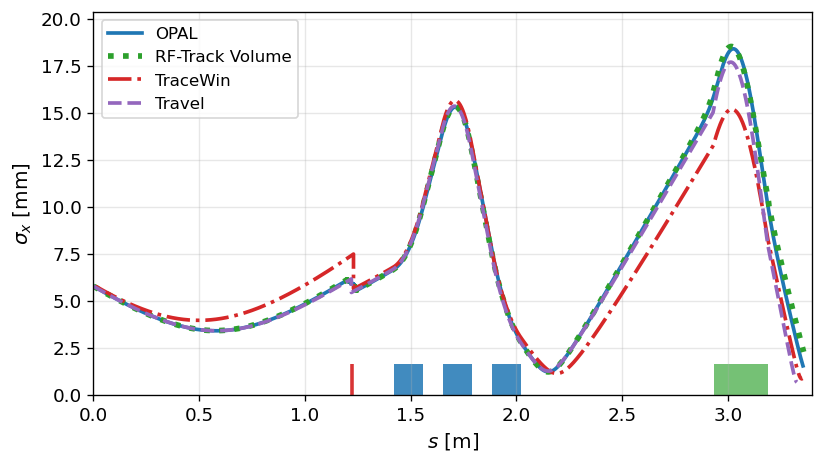

Figura guardada en: beam_plots/parameter_evolution_sc/sigma_y_evolution_sc.pdf


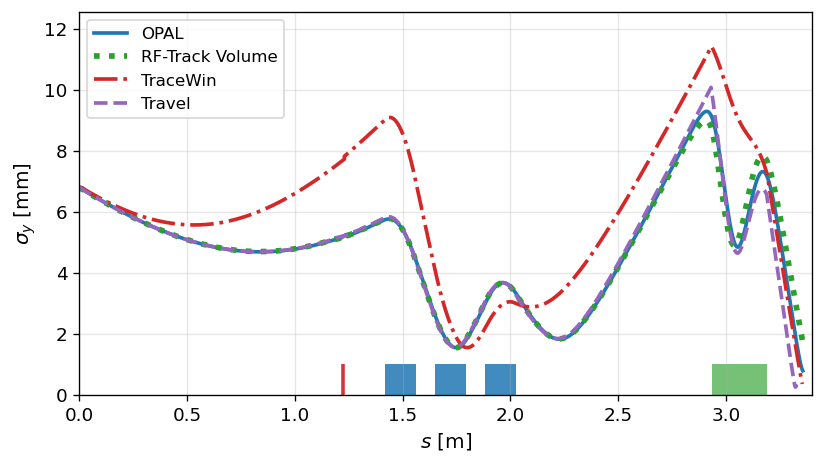

Figura guardada en: beam_plots/parameter_evolution_sc/sigma_xp_evolution_sc.pdf


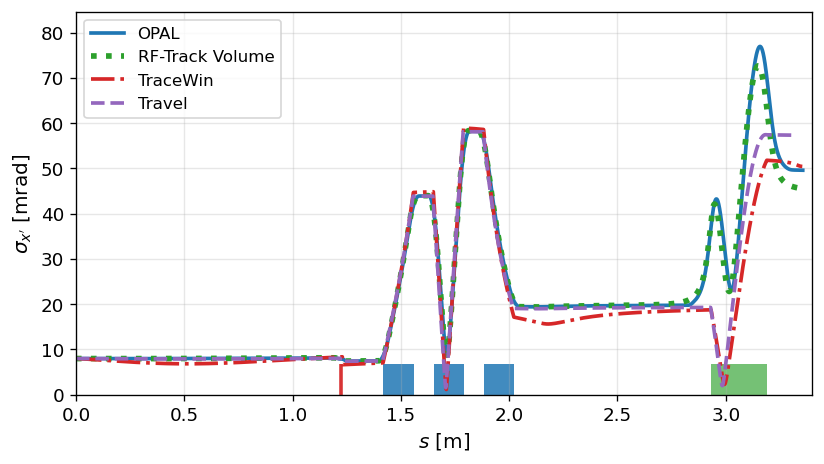

Figura guardada en: beam_plots/parameter_evolution_sc/sigma_yp_evolution_sc.pdf


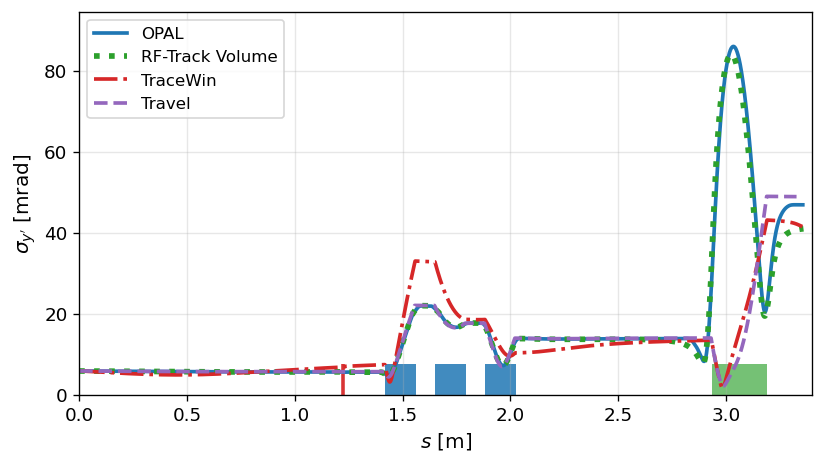

Figura guardada en: beam_plots/parameter_evolution_sc/energy_evolution_sc.pdf


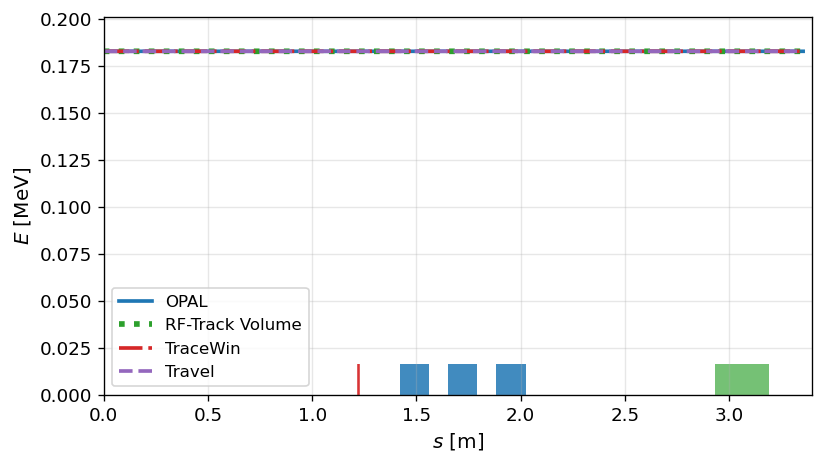

Figura guardada en: beam_plots/parameter_evolution_sc/momentum_evolution_sc.pdf


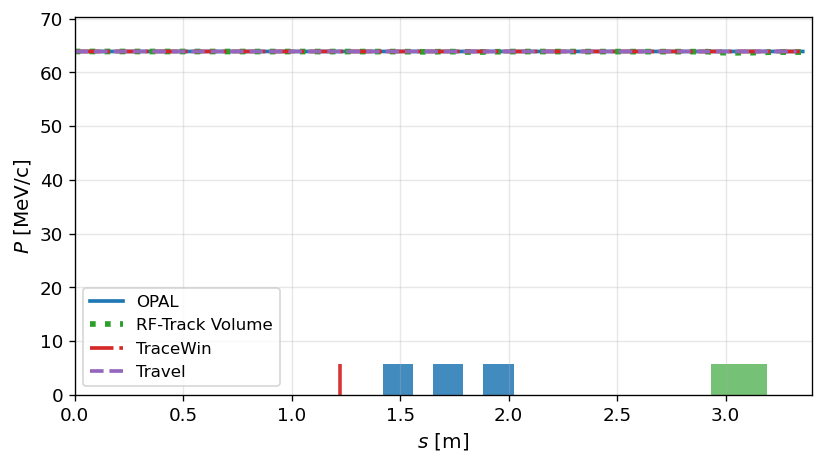

Figura guardada en: beam_plots/parameter_evolution_sc/transmission_evolution_sc.pdf


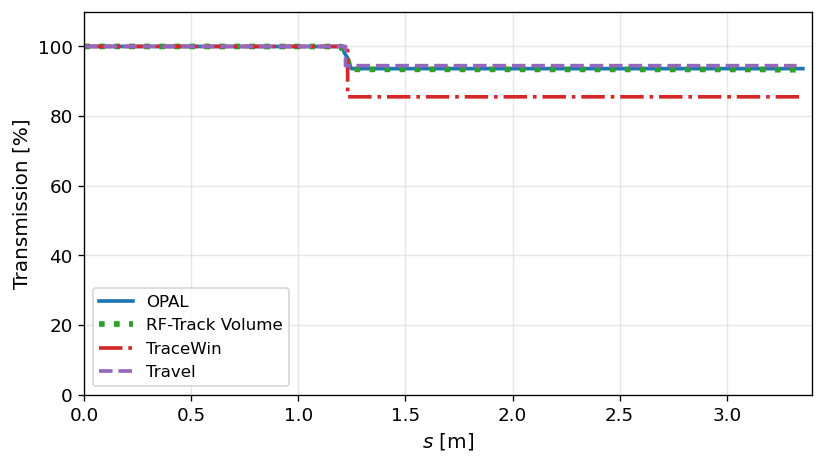

Figuras guardadas en: beam_plots/parameter_evolution_sc


In [65]:
from pathlib import Path
import numpy as np
from IPython.display import display

# ============================================================
# Variables globales necesarias para plot_param
# ============================================================

show_in_notebook = globals().get("show_in_notebook", True)

# ============================================================
# Sufijo global para benchmark con space charge
# ============================================================

OUTPUT_SUFFIX = "_sc"


def add_output_suffix(filename, suffix=OUTPUT_SUFFIX):
    """
    Añade el sufijo _sc antes de la extensión.
    """
    path = Path(filename)

    if path.stem.endswith(suffix):
        return str(path)

    if path.suffix:
        return str(path.with_name(path.stem + suffix + path.suffix))

    return str(path.with_name(path.name + suffix))


# ============================================================
# Carpeta de salida
# ============================================================

outdir = Path("beam_plots") / "parameter_evolution_sc"
outdir.mkdir(parents=True, exist_ok=True)


def out(name):
    """
    Devuelve SOLO el nombre del archivo.
    La carpeta la maneja save_figure() usando outdir.
    Si no se pasa extensión, usa .pdf.
    """
    path = Path(name)

    if path.suffix == "":
        path = path.with_suffix(".pdf")

    return path.name


# ============================================================
# Helpers robustos
# ============================================================

def to_1d_array(x):
    return np.atleast_1d(np.asarray(x, dtype=float)).ravel()


def make_curve_compatible(s, y):
    s = to_1d_array(s)
    y = to_1d_array(y)

    if len(y) == 1 and len(s) > 1:
        y = np.full_like(s, y[0], dtype=float)

    if len(s) == 1 and len(y) > 1:
        s = np.full_like(y, s[0], dtype=float)

    n = min(len(s), len(y))
    return s[:n], y[:n]


def cut_to_xlim(s, y, x_min=None, x_max=None):
    s, y = make_curve_compatible(s, y)

    if x_min is None:
        x_min = globals().get("s_min_plot", -np.inf)

    if x_max is None:
        x_max = globals().get("s_max_plot", np.inf)

    mask = (
        np.isfinite(s)
        & np.isfinite(y)
        & (s >= x_min)
        & (s <= x_max)
    )

    return s[mask], y[mask]


def transmission_to_percent(values, N0=15673, name=""):
    values = to_1d_array(values)
    finite = values[np.isfinite(values)]

    if len(finite) == 0:
        return values

    vmax = np.nanmax(finite)

    # Ya está en %
    if vmax <= 105:
        return values

    # Parece porcentaje x100
    if vmax <= 10500:
        print(f"{name}: parece transmisión en % x100. Dividiendo entre 100.")
        return values / 100.0

    # Parece número de partículas
    if vmax <= 1.2 * N0:
        print(f"{name}: parece número de partículas. Convirtiendo a %.")
        return 100.0 * values / N0

    print(f"{name}: valores de transmisión anómalos, max = {vmax:.3g}. Revisa el parser.")
    return 100.0 * values / N0


def ensure_mrad(values):
    """
    Si parece estar en rad, pasa a mrad.
    Si ya parece estar en mrad, lo deja igual.
    """
    values = to_1d_array(values)
    finite = values[np.isfinite(values)]

    if len(finite) == 0:
        return values

    med = np.nanmedian(np.abs(finite))

    if med < 1.0:
        return values * 1000.0

    return values


# ============================================================
# TraceWin arrays
# ============================================================

TRACEWIN_S_OFFSET = 0.01  # m

s_tw_x = to_1d_array(s_tracewin_x)
s_tw_y = to_1d_array(s_tracewin_y)
s_tw_env = to_1d_array(s_tracewin_envelope)
s_tw_N = to_1d_array(s_tracewin_N)

s_tw_x_draw = s_tw_x + TRACEWIN_S_OFFSET
s_tw_y_draw = s_tw_y + TRACEWIN_S_OFFSET
s_tw_env_draw = s_tw_env + TRACEWIN_S_OFFSET
s_tw_N_draw = s_tw_N + TRACEWIN_S_OFFSET

tracewin_sigma_x_plot = to_1d_array(rms_x_tracewin)
tracewin_sigma_y_plot = to_1d_array(rms_y_tracewin)

# En este notebook SC, sigma_xp_tracewin y sigma_yp_tracewin ya vienen en mrad.
# ensure_mrad evita multiplicar dos veces por 1000.
tracewin_sigma_xp_plot = ensure_mrad(sigma_xp_tracewin)
tracewin_sigma_yp_plot = ensure_mrad(sigma_yp_tracewin)

tracewin_E_plot = to_1d_array(E_tracewin)
tracewin_P_plot = to_1d_array(P_tracewin)
tracewin_T_plot = transmission_to_percent(N_tracewin, N0=15673, name="TraceWin")


# ============================================================
# TRAVEL derived arrays
# ============================================================

s_travel = to_1d_array(s_travel)

E_travel_plot = np.full_like(
    s_travel,
    float(np.asarray(E_travel).ravel()[0]),
    dtype=float
)

P_travel_plot = np.full_like(
    s_travel,
    float(np.asarray(P_travel).ravel()[0]),
    dtype=float
)

emit4D_travel = emit_x_travel * emit_y_travel

if "travel_avg" in globals() and np.asarray(travel_avg).ndim == 2 and travel_avg.shape[1] > 2:
    s_travel_N = to_1d_array(travel_avg[:, 2])
else:
    s_travel_N = s_travel

T_travel = transmission_to_percent(N_travel, N0=15673, name="TRAVEL")
s_travel_N, T_travel = make_curve_compatible(s_travel_N, T_travel)


# ============================================================
# Other derived arrays
# ============================================================

T_opal = transmission_to_percent(N_opal, N0=15673, name="OPAL")

N_rf_vol_arr = to_1d_array(N_rf_vol)
if len(N_rf_vol_arr) > 0 and np.isfinite(N_rf_vol_arr[0]) and N_rf_vol_arr[0] != 0:
    T_rf_vol = N_rf_vol_arr / N_rf_vol_arr[0] * 100.0
else:
    T_rf_vol = np.full_like(N_rf_vol_arr, np.nan)

emit4D_opal = emmit_x_opal * emmit_y_opal
emit4D_rf_vol = emitt_x_rf_vol * emitt_y_rf_vol


# ============================================================
# Labels, colores, estilos y grosores
# ============================================================

lab_opal = "OPAL"
lab_rfv = "RF-Track Volume"
lab_tw = "TraceWin"
lab_travel = "Travel"

c_opal = "tab:blue"
c_rfv = "tab:green"
c_tw = "tab:red"
c_travel = "tab:purple"

ls_opal = "-"
ls_rfv = ":"
ls_tw = "-."
ls_travel = "--"

lw_default = 2.2
lw_rfv = 3.4


# ============================================================
# RMS beam sizes
# ============================================================

plot_param(
    r"Evolución de $\sigma_x$",
    r"$\sigma_x$ [mm]",
    [
        (lab_opal, s_opal, rms_x_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, rms_x_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_x_draw, tracewin_sigma_x_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, rms_x_travel, ls_travel, c_travel, lw_default),
    ],
    out("sigma_x_evolution")
)

plot_param(
    r"Evolución de $\sigma_y$",
    r"$\sigma_y$ [mm]",
    [
        (lab_opal, s_opal, rms_y_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, rms_y_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_y_draw, tracewin_sigma_y_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, rms_y_travel, ls_travel, c_travel, lw_default),
    ],
    out("sigma_y_evolution")
)


# ============================================================
# RMS divergences
# ============================================================

plot_param(
    r"Evolución de $\sigma_{x'}$",
    r"$\sigma_{x'}$ [mrad]",
    [
        (lab_opal, s_opal, sigma_px_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, sigma_xp_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_env_draw, tracewin_sigma_xp_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, sigma_xp_travel, ls_travel, c_travel, lw_default),
    ],
    out("sigma_xp_evolution")
)

plot_param(
    r"Evolución de $\sigma_{y'}$",
    r"$\sigma_{y'}$ [mrad]",
    [
        (lab_opal, s_opal, sigma_py_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, sigma_yp_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_env_draw, tracewin_sigma_yp_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, sigma_yp_travel, ls_travel, c_travel, lw_default),
    ],
    out("sigma_yp_evolution")
)


# ============================================================
# Energy and momentum
# ============================================================

plot_param(
    r"Evolución de la energía cinética media",
    r"$E$ [MeV]",
    [
        (lab_opal, s_opal, E_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, E_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_env_draw, tracewin_E_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, E_travel_plot, ls_travel, c_travel, lw_default),
    ],
    out("energy_evolution")
)

plot_param(
    r"Evolución del momento medio",
    r"$P$ [MeV/c]",
    [
        (lab_opal, s_opal, P_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, P_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_env_draw, tracewin_P_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, P_travel_plot, ls_travel, c_travel, lw_default),
    ],
    out("momentum_evolution")
)


# ============================================================
# Transmission
# ============================================================

plot_param(
    r"Evolución de la transmisión",
    r"Transmission [%]",
    [
        (lab_opal, s_opal, T_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, T_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_N_draw, tracewin_T_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel_N, T_travel, ls_travel, c_travel, lw_default),
    ],
    out("transmission_evolution"),
    draw_lattice=False,
    auto_ylim=True
)

print(f"Figuras guardadas en: {outdir}")

## Plot rms doble

Figura guardada en: beam_plots/parameter_evolution_sc/sigma_xy_evolution_sc.pdf


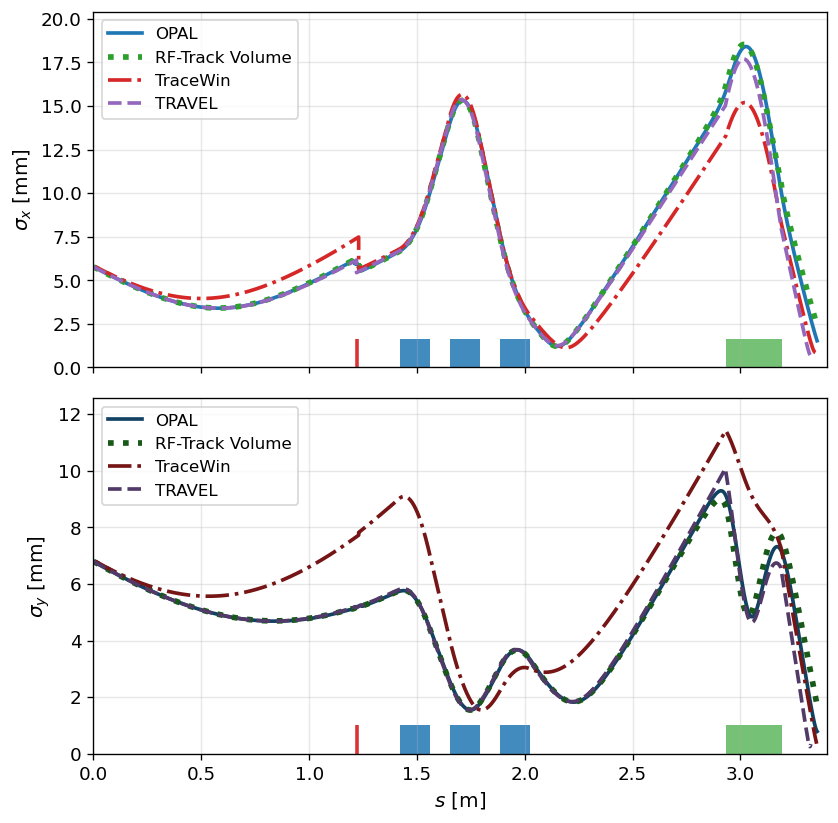

Figura guardada en: beam_plots/parameter_evolution_sc/sigma_xpyp_evolution_double_sc.pdf


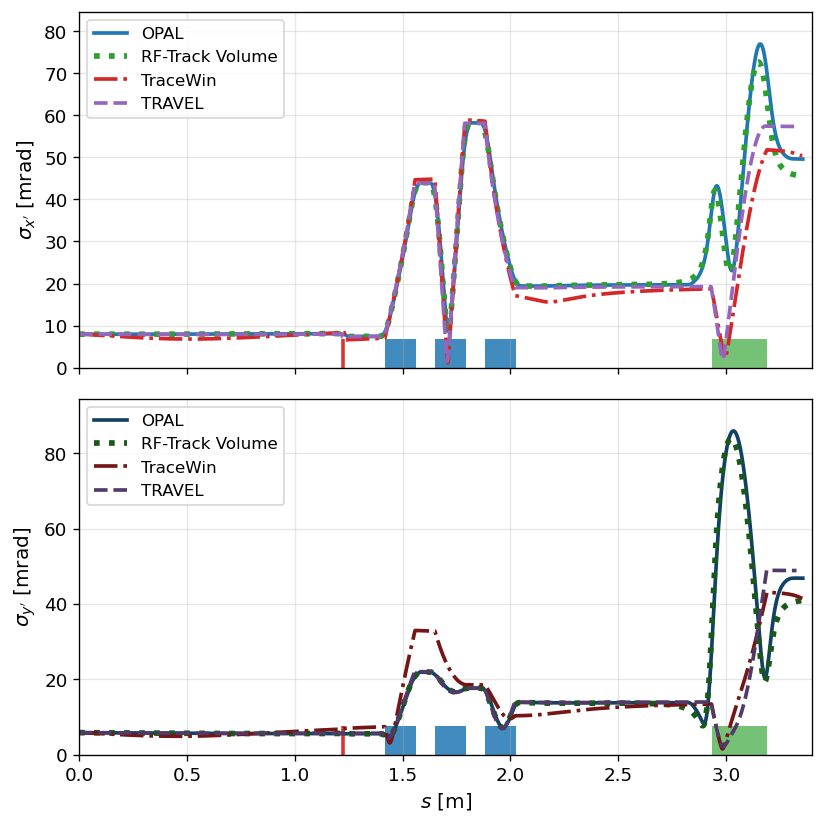

In [66]:
import numpy as np
import matplotlib.colors as mcolors

# ============================================================
# Labels, colores y grosores
# ============================================================

lab_opal = "OPAL"
lab_rfv = "RF-Track Volume"
lab_tw = "TraceWin"
lab_travel = "TRAVEL"

c_opal = "tab:blue"
c_rfv = "tab:green"
c_tw = "tab:red"
c_travel = "tab:purple"

lw_default = 2.2
lw_rfv = 3.4


def darken_color(color, factor=0.55):
    """
    Devuelve una versión más oscura del color.
    factor < 1 oscurece.
    """
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb * factor)


# Colores más oscuros para las variables y, y'
c_opal_y = darken_color(c_opal)
c_rfv_y = darken_color(c_rfv)
c_tw_y = darken_color(c_tw)
c_travel_y = darken_color(c_travel)


# ============================================================
# RMS beam sizes: sigma_x y sigma_y
# ============================================================

plot_param_double(
    r"$\sigma_x$ [mm]",
    r"$\sigma_y$ [mm]",
    [
        (lab_opal, s_opal, rms_x_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, rms_x_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_x_draw, tracewin_sigma_x_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, rms_x_travel, ls_travel, c_travel, lw_default),
    ],
    [
        (lab_opal, s_opal, rms_y_opal, ls_opal, c_opal_y, lw_default),
        (lab_rfv, s_rf_vol, rms_y_rf_vol, ls_rfv, c_rfv_y, lw_rfv),
        (lab_tw, s_tw_y_draw, tracewin_sigma_y_plot, ls_tw, c_tw_y, lw_default),
        (lab_travel, s_travel, rms_y_travel, ls_travel, c_travel_y, lw_default),
    ],
    out("sigma_xy_evolution"),
    draw_lattice=True,
    auto_ylim=True
)


# ============================================================
# RMS divergences: sigma_xp y sigma_yp
# ============================================================
# OJO: aquí NO vuelvo a multiplicar por 1000 si ya tienes:
# tracewin_sigma_xp_plot = sigma_xp_tracewin * 1000
# tracewin_sigma_yp_plot = sigma_yp_tracewin * 1000

plot_param_double(
    r"$\sigma_{x'}$ [mrad]",
    r"$\sigma_{y'}$ [mrad]",
    [
        (lab_opal, s_opal, sigma_px_opal, ls_opal, c_opal, lw_default),
        (lab_rfv, s_rf_vol, sigma_xp_rf_vol, ls_rfv, c_rfv, lw_rfv),
        (lab_tw, s_tw_env_draw, tracewin_sigma_xp_plot, ls_tw, c_tw, lw_default),
        (lab_travel, s_travel, sigma_xp_travel, ls_travel, c_travel, lw_default),
    ],
    [
        (lab_opal, s_opal, sigma_py_opal, ls_opal, c_opal_y, lw_default),
        (lab_rfv, s_rf_vol, sigma_yp_rf_vol, ls_rfv, c_rfv_y, lw_rfv),
        (lab_tw, s_tw_env_draw, tracewin_sigma_yp_plot, ls_tw, c_tw_y, lw_default),
        (lab_travel, s_travel, sigma_yp_travel, ls_travel, c_travel_y, lw_default),
    ],
    out("sigma_xpyp_evolution_double"),
    draw_lattice=True,
    auto_ylim=False
)

## Comparador Elipses

Guardado en: elipses finales/ellipses_90_opal_rftrack_volume.pdf


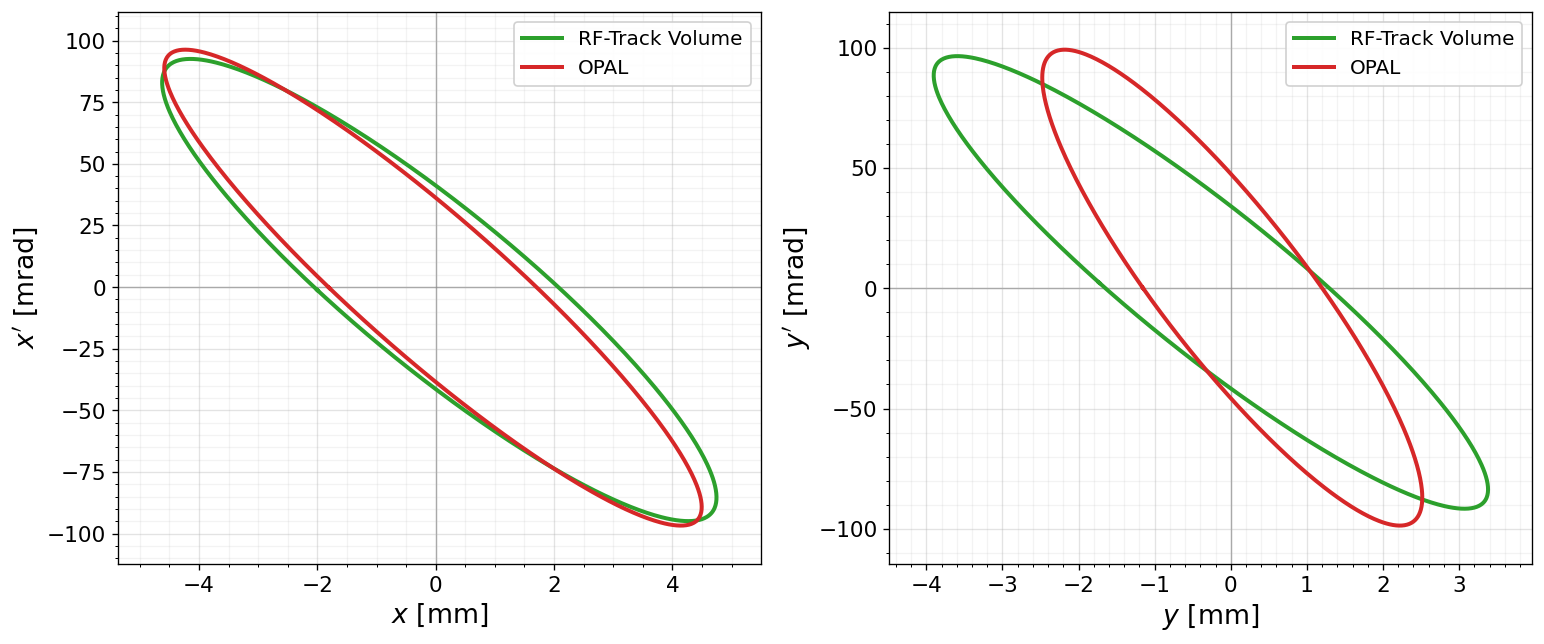

,Code,Plane,N,fraction target,fraction check,emit_rms [mm mrad],emit_90 [mm mrad],alpha,beta [mm/mrad],gamma [mrad/mm],sigma_pos [mm],sigma_div [mrad],mean_pos [mm],mean_div [mrad],scale
0,RF-Track Volume,x-xp,14623,0.9,0.899952,45.723466,193.348975,2.037959,0.113424,45.433661,2.277312,45.578333,0.061290,-1.171796,2.056371
1,RF-Track Volume,y-yp,14623,0.9,0.899952,26.403788,138.400645,2.263474,0.095823,63.902466,1.590624,41.076358,-0.261282,2.411897,2.289475
2,OPAL,x-xp,14203,0.9,0.899951,45.859786,169.597485,2.382169,0.121539,54.918620,2.360875,50.185219,-0.045843,-0.206131,1.923064
3,OPAL,y-yp,14203,0.9,0.899951,24.817247,116.422078,1.869890,0.053529,84.000589,1.152583,45.658114,0.019665,0.249171,2.165912


Guardado en: elipses finales/ellipses_90_tracewin_travel.pdf


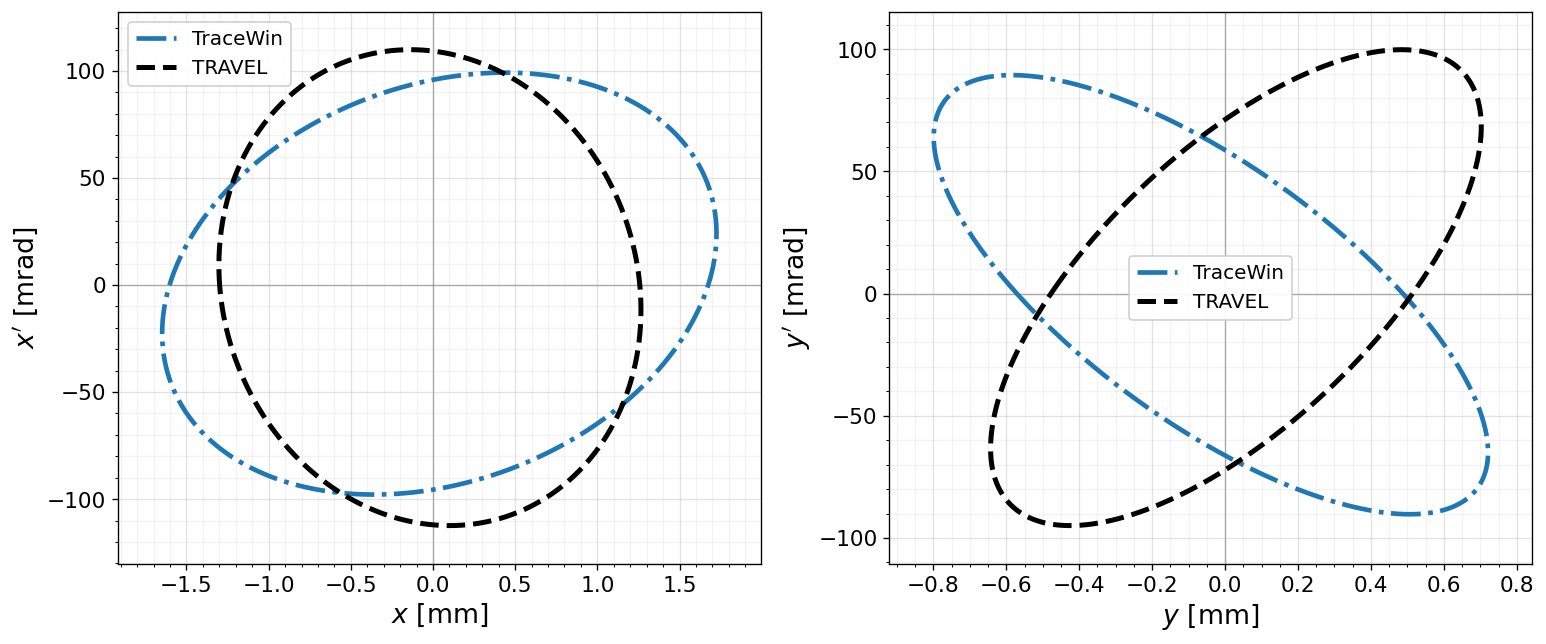

,Code,Plane,N,fraction target,fraction check,emit_rms [mm mrad],emit_90 [mm mrad],alpha,beta [mm/mrad],gamma [mrad/mm],sigma_pos [mm],sigma_div [mrad],mean_pos [mm],mean_div [mrad],scale
0,TraceWin,x-xp,13406,0.9,0.89997,42.281854,161.481664,-0.243323,0.017615,60.129773,0.863023,50.422200,0.038426,0.675172,1.954270
1,TraceWin,y-yp,13406,0.9,0.89997,10.149611,47.550677,1.030528,0.012151,169.696636,0.351181,41.501262,-0.038885,-0.474861,2.164480
2,TRAVEL,x-xp,14807,0.9,0.89998,37.799299,142.104148,0.093795,0.011603,86.939310,0.662271,57.325780,-0.018744,-1.213080,1.938927
3,TRAVEL,y-yp,14807,0.9,0.89998,12.184915,48.287679,-0.916534,0.009375,196.274514,0.337981,48.903867,0.029804,2.413105,1.990705


Guardado en: elipses finales/ellipses_90_sc_vs_no_sc_4subplots_x-xp.pdf
Guardado en: elipses finales/ellipses_90_sc_vs_no_sc_4subplots_x-xp.png
Tabla guardada en: elipses finales/ellipses_90_sc_vs_no_sc_4subplots_x-xp.csv


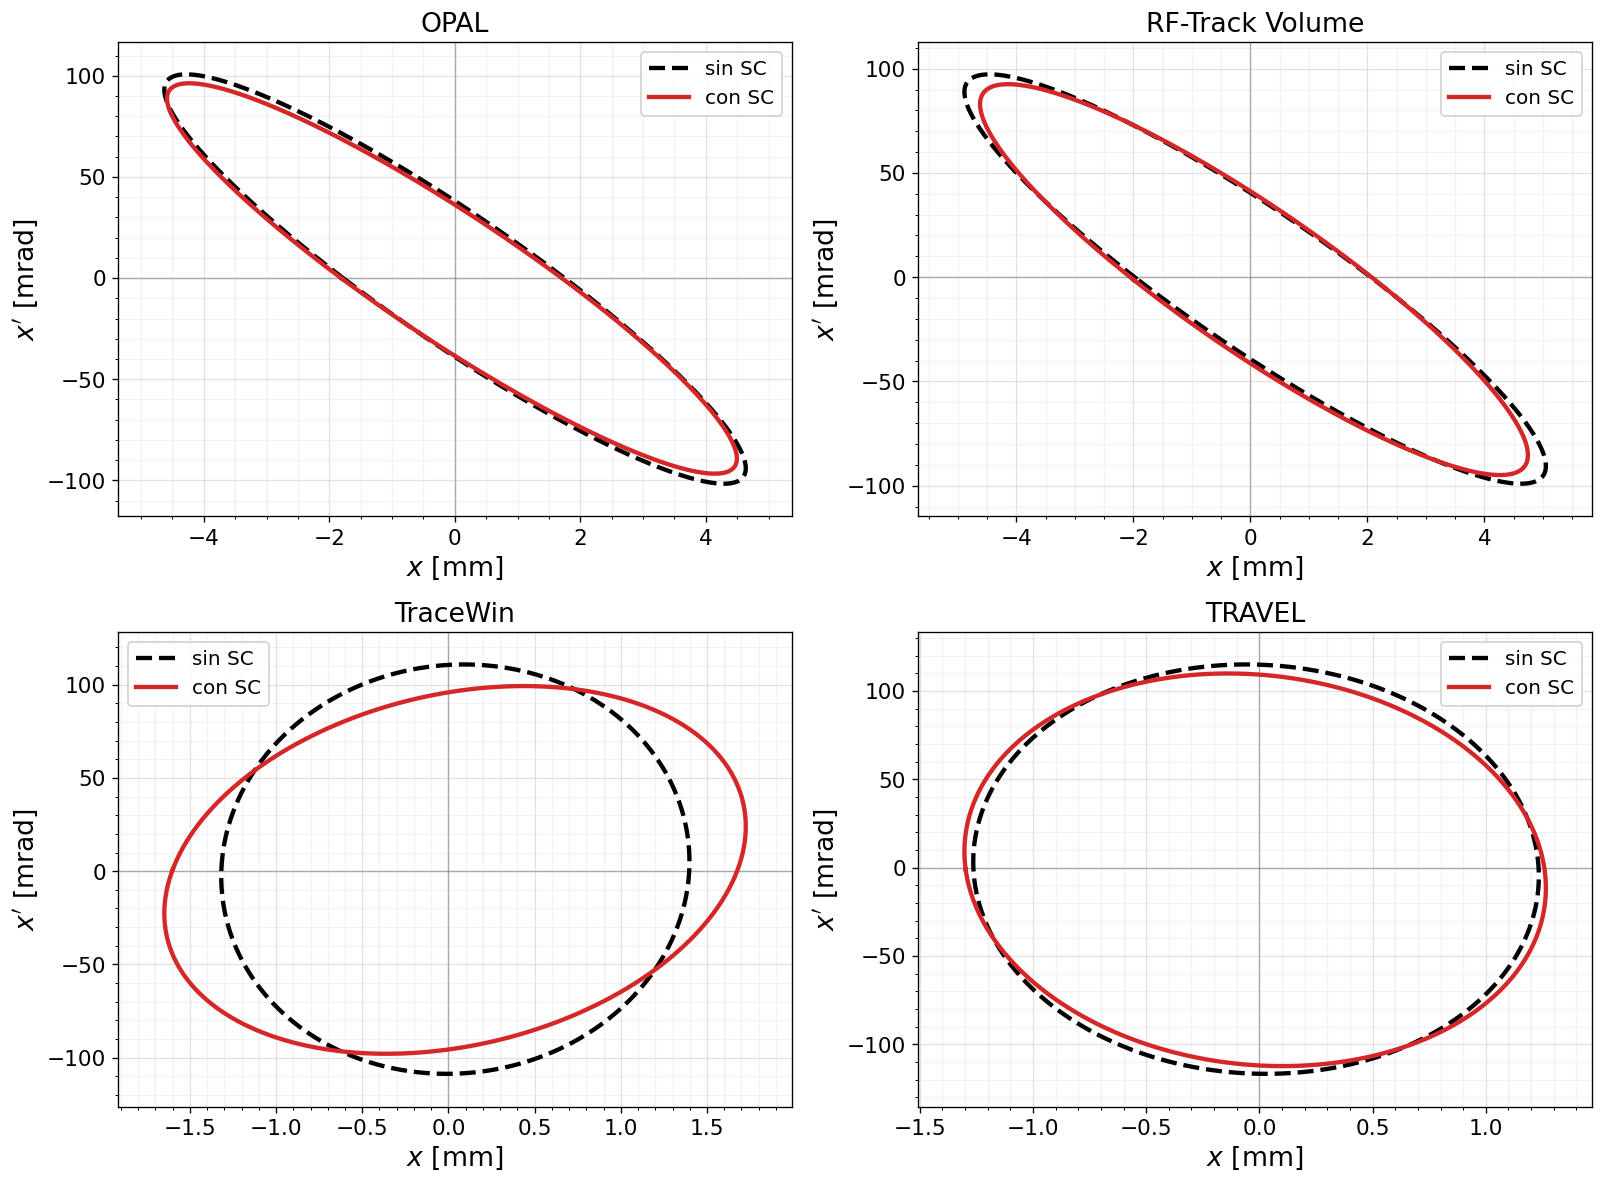

,Code,Plane,N sin SC,N con SC,emit_90 sin SC [mm mrad],emit_90 con SC [mm mrad],Delta emit_90 [%],sigma_pos sin SC [mm],sigma_pos con SC [mm],sigma_div sin SC [mrad],sigma_div con SC [mrad]
0,OPAL,x-xp,14710,14203,178.548385,169.597485,-5.013151,2.402003,2.360875,52.475707,50.185219
1,RF-Track Volume,x-xp,14825,14623,198.225847,193.348975,-2.460260,2.429710,2.277312,47.987409,45.578333
2,TraceWin,x-xp,14861,13406,148.892833,161.481664,8.454961,0.699788,0.863023,56.528653,50.422200
3,TRAVEL,x-xp,14867,14807,144.663004,142.104148,-1.768839,0.642373,0.662271,59.601535,57.325780


Guardado en: elipses finales/ellipses_90_sc_vs_no_sc_4subplots_y-yp.pdf
Guardado en: elipses finales/ellipses_90_sc_vs_no_sc_4subplots_y-yp.png
Tabla guardada en: elipses finales/ellipses_90_sc_vs_no_sc_4subplots_y-yp.csv


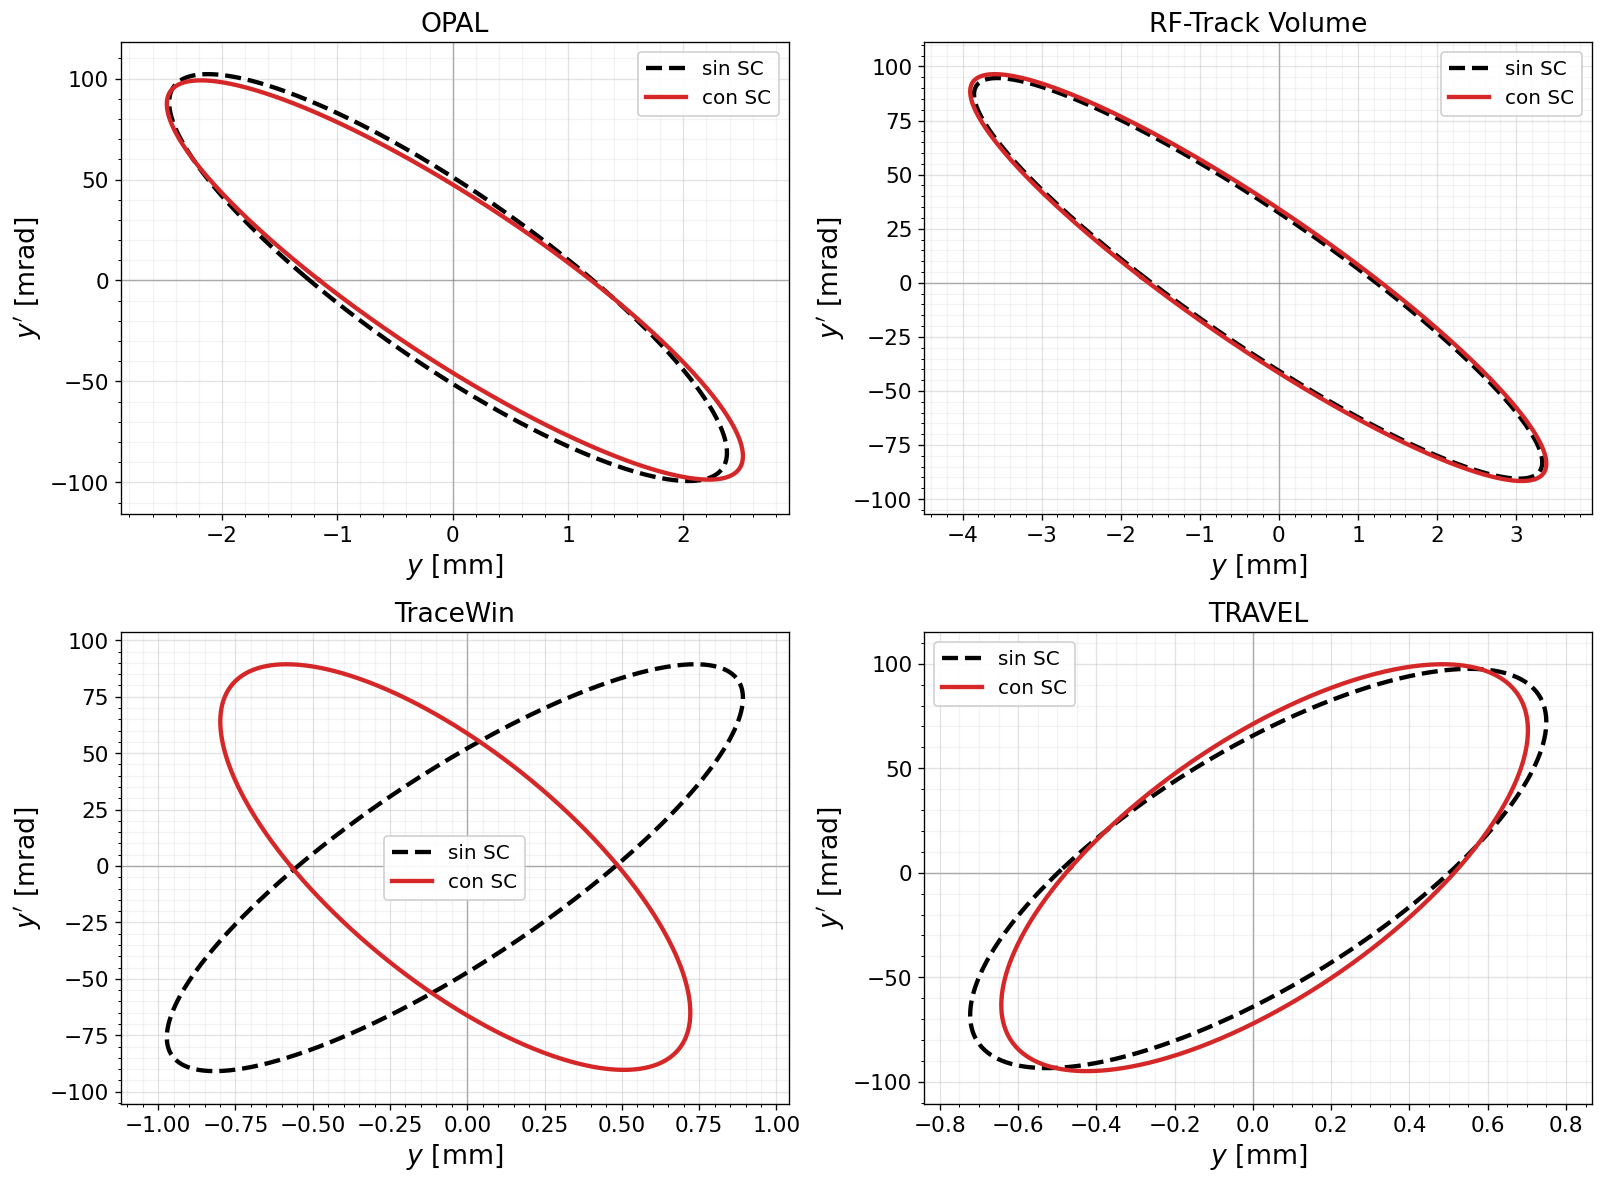

,Code,Plane,N sin SC,N con SC,emit_90 sin SC [mm mrad],emit_90 con SC [mm mrad],Delta emit_90 [%],sigma_pos sin SC [mm],sigma_pos con SC [mm],sigma_div sin SC [mrad],sigma_div con SC [mrad]
0,OPAL,y-yp,14710,14203,123.787297,116.422078,-5.949899,1.115089,1.152583,46.496200,45.658114
1,RF-Track Volume,y-yp,14825,14623,131.537433,138.400645,5.217687,1.588658,1.590624,40.955075,41.076358
2,TraceWin,y-yp,14861,13406,46.302873,47.550677,2.694875,0.465899,0.351181,45.058229,41.501262
3,TRAVEL,y-yp,14867,14807,47.766479,48.287679,1.091143,0.374804,0.337981,48.641566,48.903867


Guardado en: elipses finales/ellipses_90_sc_vs_no_sc_xy_together_4subplots.pdf
Guardado en: elipses finales/ellipses_90_sc_vs_no_sc_xy_together_4subplots.png
Tabla guardada en: elipses finales/ellipses_90_sc_vs_no_sc_xy_together_4subplots.csv


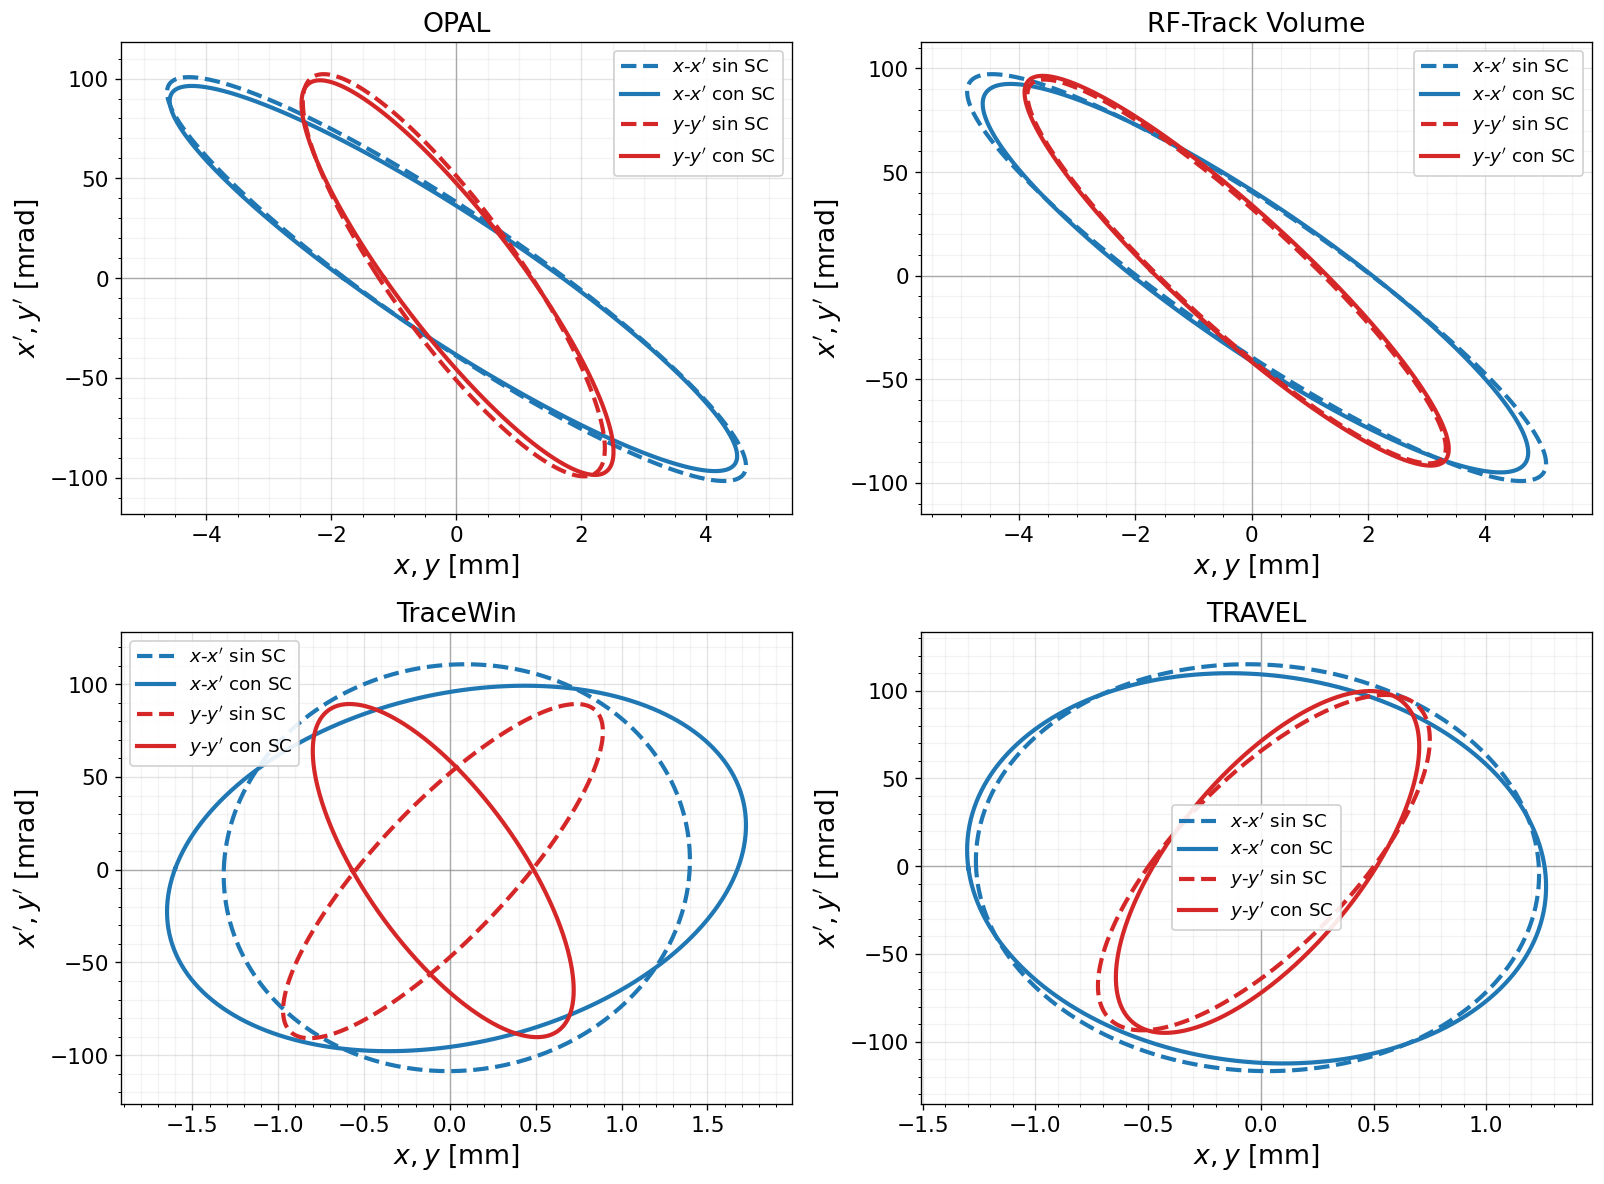

,Code,Plane,N sin SC,N con SC,emit_90 sin SC [mm mrad],emit_90 con SC [mm mrad],Delta emit_90 [%],sigma_pos sin SC [mm],sigma_pos con SC [mm],sigma_div sin SC [mrad],sigma_div con SC [mrad]
0,OPAL,x-xp,14710,14203,178.548385,169.597485,-5.013151,2.402003,2.360875,52.475707,50.185219
1,OPAL,y-yp,14710,14203,123.787297,116.422078,-5.949899,1.115089,1.152583,46.496200,45.658114
2,RF-Track Volume,x-xp,14825,14623,198.225847,193.348975,-2.460260,2.429710,2.277312,47.987409,45.578333
3,RF-Track Volume,y-yp,14825,14623,131.537433,138.400645,5.217687,1.588658,1.590624,40.955075,41.076358
4,TraceWin,x-xp,14861,13406,148.892833,161.481664,8.454961,0.699788,0.863023,56.528653,50.422200
5,TraceWin,y-yp,14861,13406,46.302873,47.550677,2.694875,0.465899,0.351181,45.058229,41.501262
6,TRAVEL,x-xp,14867,14807,144.663004,142.104148,-1.768839,0.642373,0.662271,59.601535,57.325780
7,TRAVEL,y-yp,14867,14807,47.766479,48.287679,1.091143,0.374804,0.337981,48.641566,48.903867


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from IPython.display import display


# ============================================================
# LOADERS
# ============================================================

def load_travel_phase_space(path):
    """
    TRAVEL:
        x [cm], x' [rad], y [cm], y' [rad],
        Phase [rad], Kinetic Energy [MeV],
        Charge State, Rest Mass [GeV/c2]

    Devuelve:
        x, y   en mm
        xp, yp en mrad
    """

    path = Path(path)

    text = path.read_text().replace("D", "E")
    lines = text.splitlines()

    data = np.loadtxt(lines[1:])
    data = np.atleast_2d(data)

    return {
        "x":  data[:, 0] * 10.0,    # cm -> mm
        "xp": data[:, 1] * 1e3,     # rad -> mrad
        "y":  data[:, 2] * 10.0,    # cm -> mm
        "yp": data[:, 3] * 1e3      # rad -> mrad
    }


def load_rftrack_phase_space(path, divergence_unit="mrad"):
    """
    RF-Track:
        X [mm], xp, Y [mm], yp

    divergence_unit:
        "mrad" si xp,yp ya están en mrad
        "rad"  si xp,yp están en rad

    Devuelve:
        x, y   en mm
        xp, yp en mrad
    """

    path = Path(path)

    data = np.loadtxt(path, comments="#")
    data = np.atleast_2d(data)

    divergence_unit = divergence_unit.lower()

    if divergence_unit == "rad":
        div_scale = 1e3
    elif divergence_unit == "mrad":
        div_scale = 1.0
    else:
        raise ValueError("divergence_unit debe ser 'rad' o 'mrad'.")

    return {
        "x":  data[:, 0],                 # mm
        "xp": data[:, 1] * div_scale,     # -> mrad
        "y":  data[:, 2],                 # mm
        "yp": data[:, 3] * div_scale      # -> mrad
    }


def load_rftrack_vol_phase_space(
    path="rftrack/rftrack_vol_phase_space.txt",
    divergence_unit="mrad"
):
    """
    RF-Track Volume:
        X [mm], xp, Y [mm], yp
    """

    return load_rftrack_phase_space(
        path,
        divergence_unit=divergence_unit
    )


def load_opal_phase_space(path):
    """
    OPAL:
        x [m], y [m], z [m], px, py, pz, id, time [s]

    Devuelve:
        x, y   en mm
        xp, yp en mrad

    En OPAL:
        x' = px / pz
        y' = py / pz
    """

    path = Path(path)

    data = np.loadtxt(path, comments="#")
    data = np.atleast_2d(data)

    x_m = data[:, 0]
    y_m = data[:, 1]

    px = data[:, 3]
    py = data[:, 4]
    pz = data[:, 5]

    mask = np.isfinite(x_m) & np.isfinite(y_m)
    mask &= np.isfinite(px) & np.isfinite(py) & np.isfinite(pz)
    mask &= np.abs(pz) > 0

    return {
        "x":  x_m[mask] * 1e3,                  # m -> mm
        "xp": (px[mask] / pz[mask]) * 1e3,      # rad -> mrad
        "y":  y_m[mask] * 1e3,                  # m -> mm
        "yp": (py[mask] / pz[mask]) * 1e3       # rad -> mrad
    }


def load_tracewin_phase_space(path):
    """
    TraceWin:
        x [mm], x' [mrad], y [mm], y' [mrad],
        z [mm], z' [mrad], Phase [deg], Time [s], Energy [MeV], Loss

    Devuelve:
        x, y   en mm
        xp, yp en mrad
    """

    path = Path(path)

    data = np.loadtxt(path, skiprows=3, comments="#")
    data = np.atleast_2d(data)

    x  = data[:, 0]   # mm
    xp = data[:, 1]   # mrad
    y  = data[:, 2]   # mm
    yp = data[:, 3]   # mrad

    # Si existe columna Loss, quedarse con partículas no perdidas
    if data.shape[1] >= 10:
        loss = data[:, 9]
        mask_loss = (loss == 0) | ~np.isfinite(loss)
    else:
        mask_loss = np.ones(len(x), dtype=bool)

    mask = (
        np.isfinite(x)
        & np.isfinite(xp)
        & np.isfinite(y)
        & np.isfinite(yp)
        & mask_loss
    )

    return {
        "x":  x[mask],      # mm
        "xp": xp[mask],     # mrad
        "y":  y[mask],      # mm
        "yp": yp[mask],     # mrad
    }


# ============================================================
# ELIPSE RMS ESCALADA AL 90%
# ============================================================

def rms_ellipse_from_phase_space(
    a,
    b,
    contain_fraction=0.90,
    npoints=600
):
    """
    Calcula una elipse RMS escalada para contener una fracción dada
    de partículas en el espacio de fases.

    a, b:
        Por ejemplo:
            a = x  [mm]
            b = xp [mrad]

    contain_fraction:
        0.90 -> elipse que contiene el 90% de las partículas.

    La orientación y forma salen de la matriz de covarianza RMS.
    El tamaño se escala usando la distancia de Mahalanobis de las partículas.
    """

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    mask = np.isfinite(a) & np.isfinite(b)
    a = a[mask]
    b = b[mask]

    if len(a) < 3:
        raise ValueError("No hay suficientes partículas para calcular la elipse.")

    q = np.column_stack([a, b])

    mean = np.mean(q, axis=0)
    q0 = q - mean

    Sigma = np.cov(q0.T, bias=True)

    emit_rms = np.sqrt(np.linalg.det(Sigma))

    if emit_rms <= 0 or not np.isfinite(emit_rms):
        raise ValueError("La matriz de covarianza no define una elipse válida.")

    beta = Sigma[0, 0] / emit_rms
    alpha = -Sigma[0, 1] / emit_rms
    gamma = Sigma[1, 1] / emit_rms

    # Distancia de Mahalanobis al cuadrado:
    # d^2 = (q - mean)^T Sigma^{-1} (q - mean)
    Sigma_inv = np.linalg.pinv(Sigma)
    d2 = np.einsum("ij,jk,ik->i", q0, Sigma_inv, q0)

    q_level = np.quantile(d2, contain_fraction)
    scale = np.sqrt(q_level)

    eigvals, eigvecs = np.linalg.eigh(Sigma)
    eigvals = np.maximum(eigvals, 0.0)

    theta = np.linspace(0, 2 * np.pi, npoints)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    ellipse = mean[:, None] + scale * eigvecs @ np.diag(np.sqrt(eigvals)) @ circle

    # Emitancia asociada al área de la elipse 90%
    # Área = pi * emit_90
    emit_90 = q_level * emit_rms

    fraction_check = np.mean(d2 <= q_level)

    info = {
        "mean_a": mean[0],
        "mean_b": mean[1],
        "emit_rms": emit_rms,
        "emit_90": emit_90,
        "alpha": alpha,
        "beta": beta,
        "gamma": gamma,
        "sigma_a": np.sqrt(Sigma[0, 0]),
        "sigma_b": np.sqrt(Sigma[1, 1]),
        "n_particles": len(a),
        "contain_fraction": contain_fraction,
        "fraction_check": fraction_check,
        "q_level": q_level,
        "scale": scale,
    }

    return ellipse[0], ellipse[1], info


# ============================================================
# PLOT DE ELIPSES
# ============================================================

def plot_rms_ellipses_codes(
    codes,
    filename="ellipses_comparison",
    outdir="elipses finales",
    contain_fraction=0.90,
    save=True,
    show=True,
    figsize=(13, 5.5),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=12,
    default_linewidth=2.2
):
    """
    Compara elipses en:
        x-x'
        y-y'

    Todas las entradas de codes deben estar en:
        x, y   -> mm
        xp, yp -> mrad

    contain_fraction:
        0.90 -> elipse que contiene el 90% de las partículas.
    """

    styles = {
        "TRAVEL": {
            "color": "black",
            "linestyle": "--",
            "linewidth": 3.0,
            "zorder": 20
        },
        "TraceWin": {
            "color": "tab:blue",
            "linestyle": "-.",
            "linewidth": 2.8,
            "zorder": 15
        },
        "RF-Track Volume": {
            "color": "tab:green",
            "linestyle": "-",
            "linewidth": 2.4,
            "zorder": 5
        },
        "OPAL": {
            "color": "tab:red",
            "linestyle": "-",
            "linewidth": 2.4,
            "zorder": 6
        }
    }

    plot_order = [
        "RF-Track Volume",
        "OPAL",
        "TraceWin",
        "TRAVEL"
    ]

    plot_order = [name for name in plot_order if name in codes] + [
        name for name in codes.keys() if name not in plot_order
    ]

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    results = []

    for code_name in plot_order:

        data = codes[code_name]

        style = styles.get(
            code_name,
            {
                "linewidth": default_linewidth,
                "zorder": 3
            }
        )

        # ----------------------------
        # Plano x-x'
        # ----------------------------
        ex, exp, info_x = rms_ellipse_from_phase_space(
            data["x"],
            data["xp"],
            contain_fraction=contain_fraction
        )

        axs[0].plot(
            ex,
            exp,
            label=code_name,
            **style
        )

        results.append({
            "Code": code_name,
            "Plane": "x-xp",
            "N": info_x["n_particles"],
            "fraction target": info_x["contain_fraction"],
            "fraction check": info_x["fraction_check"],
            "emit_rms [mm mrad]": info_x["emit_rms"],
            "emit_90 [mm mrad]": info_x["emit_90"],
            "alpha": info_x["alpha"],
            "beta [mm/mrad]": info_x["beta"],
            "gamma [mrad/mm]": info_x["gamma"],
            "sigma_pos [mm]": info_x["sigma_a"],
            "sigma_div [mrad]": info_x["sigma_b"],
            "mean_pos [mm]": info_x["mean_a"],
            "mean_div [mrad]": info_x["mean_b"],
            "scale": info_x["scale"],
        })

        # ----------------------------
        # Plano y-y'
        # ----------------------------
        ey, eyp, info_y = rms_ellipse_from_phase_space(
            data["y"],
            data["yp"],
            contain_fraction=contain_fraction
        )

        axs[1].plot(
            ey,
            eyp,
            label=code_name,
            **style
        )

        results.append({
            "Code": code_name,
            "Plane": "y-yp",
            "N": info_y["n_particles"],
            "fraction target": info_y["contain_fraction"],
            "fraction check": info_y["fraction_check"],
            "emit_rms [mm mrad]": info_y["emit_rms"],
            "emit_90 [mm mrad]": info_y["emit_90"],
            "alpha": info_y["alpha"],
            "beta [mm/mrad]": info_y["beta"],
            "gamma [mrad/mm]": info_y["gamma"],
            "sigma_pos [mm]": info_y["sigma_a"],
            "sigma_div [mrad]": info_y["sigma_b"],
            "mean_pos [mm]": info_y["mean_a"],
            "mean_div [mrad]": info_y["mean_b"],
            "scale": info_y["scale"],
        })

    axs[0].set_xlabel(r"$x$ [mm]", fontsize=label_fontsize)
    axs[0].set_ylabel(r"$x'$ [mrad]", fontsize=label_fontsize)

    axs[1].set_xlabel(r"$y$ [mm]", fontsize=label_fontsize)
    axs[1].set_ylabel(r"$y'$ [mrad]", fontsize=label_fontsize)

    for ax in axs:
        ax.axhline(0, color="black", linewidth=0.8, alpha=0.35, zorder=0)
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.35, zorder=0)

        ax.grid(True, which="major", alpha=0.35)
        ax.minorticks_on()
        ax.grid(True, which="minor", alpha=0.15)

        ax.tick_params(axis="both", labelsize=tick_fontsize)

        ax.legend(
            fontsize=legend_fontsize,
            framealpha=0.9,
            loc="best"
        )

        ax.margins(x=0.08, y=0.08)

    fig.tight_layout()

    if save:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)

        pdf_path = outdir / f"{filename}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")

        print(f"Guardado en: {pdf_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return pd.DataFrame(results)


# ============================================================
# CARGA DE DATOS
# ============================================================

travel = load_travel_phase_space(
    "space_charge/travel_sc_phase.txt"
)

opal = load_opal_phase_space(
    "space_charge/opal_sc_1mA_phase_space.loss"
)

tracewin = load_tracewin_phase_space(
    "space_charge/output_lebt_tracewin_SC_1mA.txt"
)

rftrack_vol = load_rftrack_vol_phase_space(
    "space_charge/rftrack_sc_1mA_phase_space.txt",
    divergence_unit="mrad"
)


# ============================================================
# PLOT 1: OPAL + RF-TRACK VOLUME
# ============================================================

codes_opal_rftrack_volume = {
    "OPAL": opal,
    "RF-Track Volume": rftrack_vol,
}

table_opal_rftrack_volume = plot_rms_ellipses_codes(
    codes_opal_rftrack_volume,
    filename="ellipses_90_opal_rftrack_volume",
    contain_fraction=0.90
)

display(table_opal_rftrack_volume)


# ============================================================
# PLOT 2: TRACEWIN + TRAVEL
# ============================================================

codes_tracewin_travel = {
    "TraceWin": tracewin,
    "TRAVEL": travel,
}

table_tracewin_travel = plot_rms_ellipses_codes(
    codes_tracewin_travel,
    filename="ellipses_90_tracewin_travel",
    contain_fraction=0.90
)

display(table_tracewin_travel)

# ============================================================
# PLOT FINAL: COMPARACIÓN ELIPSES CON SC vs SIN SC
# ============================================================

def plot_sc_vs_no_sc_ellipses_4subplots(
    codes_no_sc,
    codes_sc,
    plane="x",
    filename="ellipses_90_sc_vs_no_sc",
    outdir="elipses finales",
    contain_fraction=0.90,
    figsize=(13.5, 10.0),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=12,
    linewidth=2.6,
    save=True,
    show=True
):
    """
    Genera una figura 2x2 con una comparación por código:

        - línea discontinua negra: sin carga espacial
        - línea continua roja: con carga espacial

    plane:
        "x" -> compara elipses en x-x'
        "y" -> compara elipses en y-y'
    """

    if plane == "x":
        a_key = "x"
        b_key = "xp"
        xlabel = r"$x$ [mm]"
        ylabel = r"$x'$ [mrad]"
        plane_name = "x-xp"
    elif plane == "y":
        a_key = "y"
        b_key = "yp"
        xlabel = r"$y$ [mm]"
        ylabel = r"$y'$ [mrad]"
        plane_name = "y-yp"
    else:
        raise ValueError("plane debe ser 'x' o 'y'.")

    code_order = [
        "OPAL",
        "RF-Track Volume",
        "TraceWin",
        "TRAVEL",
    ]

    code_order = [
        code for code in code_order
        if code in codes_no_sc and code in codes_sc
    ]

    if len(code_order) == 0:
        raise RuntimeError("No hay códigos comunes entre sin SC y con SC.")

    fig, axs = plt.subplots(
        2,
        2,
        figsize=figsize
    )

    axs = axs.ravel()

    rows = []

    for ax, code_name in zip(axs, code_order):

        data_no_sc = codes_no_sc[code_name]
        data_sc = codes_sc[code_name]

        # ----------------------------
        # Elipse sin SC
        # ----------------------------
        e_no_a, e_no_b, info_no = rms_ellipse_from_phase_space(
            data_no_sc[a_key],
            data_no_sc[b_key],
            contain_fraction=contain_fraction
        )

        ax.plot(
            e_no_a,
            e_no_b,
            color="black",
            linestyle="--",
            linewidth=linewidth,
            label="sin SC"
        )

        # ----------------------------
        # Elipse con SC
        # ----------------------------
        e_sc_a, e_sc_b, info_sc = rms_ellipse_from_phase_space(
            data_sc[a_key],
            data_sc[b_key],
            contain_fraction=contain_fraction
        )

        ax.plot(
            e_sc_a,
            e_sc_b,
            color="tab:red",
            linestyle="-",
            linewidth=linewidth,
            label="con SC"
        )

        ax.set_title(code_name, fontsize=label_fontsize)
        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

        ax.axhline(0, color="black", linewidth=0.8, alpha=0.35, zorder=0)
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.35, zorder=0)

        ax.grid(True, which="major", alpha=0.35)
        ax.minorticks_on()
        ax.grid(True, which="minor", alpha=0.15)

        ax.tick_params(axis="both", labelsize=tick_fontsize)

        ax.legend(
            fontsize=legend_fontsize,
            framealpha=0.9,
            loc="best"
        )

        ax.margins(x=0.08, y=0.08)

        rows.append({
            "Code": code_name,
            "Plane": plane_name,
            "N sin SC": info_no["n_particles"],
            "N con SC": info_sc["n_particles"],
            "emit_90 sin SC [mm mrad]": info_no["emit_90"],
            "emit_90 con SC [mm mrad]": info_sc["emit_90"],
            "Delta emit_90 [%]": 100.0 * (
                info_sc["emit_90"] - info_no["emit_90"]
            ) / info_no["emit_90"],
            "sigma_pos sin SC [mm]": info_no["sigma_a"],
            "sigma_pos con SC [mm]": info_sc["sigma_a"],
            "sigma_div sin SC [mrad]": info_no["sigma_b"],
            "sigma_div con SC [mrad]": info_sc["sigma_b"],
        })

    # Si hubiera menos de 4 códigos, oculta ejes vacíos
    for ax in axs[len(code_order):]:
        ax.axis("off")

    fig.tight_layout()

    results = pd.DataFrame(rows)

    if save:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)

        pdf_path = outdir / f"{filename}_{plane_name}.pdf"
        png_path = outdir / f"{filename}_{plane_name}.png"
        csv_path = outdir / f"{filename}_{plane_name}.csv"

        fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        results.to_csv(csv_path, index=False)

        print(f"Guardado en: {pdf_path}")
        print(f"Guardado en: {png_path}")
        print(f"Tabla guardada en: {csv_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return results


# ============================================================
# CARGA DE DATOS SIN SPACE CHARGE
# ============================================================

travel_no_sc = load_travel_phase_space(
    "travel/lebt_travel.txt"
)

opal_no_sc = load_opal_phase_space(
    "opal/opal_phase_space.loss"
)

tracewin_no_sc = load_tracewin_phase_space(
    "inputs/output_lebt_tracewin_noSC.txt"
)

rftrack_vol_no_sc = load_rftrack_vol_phase_space(
    "rftrack/rftrack_vol_phase_space.txt",
    divergence_unit="mrad"
)


# ============================================================
# DICCIONARIOS CON Y SIN SPACE CHARGE
# ============================================================

codes_no_sc_all = {
    "OPAL": opal_no_sc,
    "RF-Track Volume": rftrack_vol_no_sc,
    "TraceWin": tracewin_no_sc,
    "TRAVEL": travel_no_sc,
}

codes_sc_all = {
    "OPAL": opal,
    "RF-Track Volume": rftrack_vol,
    "TraceWin": tracewin,
    "TRAVEL": travel,
}


# ============================================================
# FIGURA 2x2: x-x'
# ============================================================

table_sc_vs_no_sc_x = plot_sc_vs_no_sc_ellipses_4subplots(
    codes_no_sc_all,
    codes_sc_all,
    plane="x",
    filename="ellipses_90_sc_vs_no_sc_4subplots",
    contain_fraction=0.90
)

display(table_sc_vs_no_sc_x)


# ============================================================
# FIGURA 2x2: y-y'
# ============================================================

table_sc_vs_no_sc_y = plot_sc_vs_no_sc_ellipses_4subplots(
    codes_no_sc_all,
    codes_sc_all,
    plane="y",
    filename="ellipses_90_sc_vs_no_sc_4subplots",
    contain_fraction=0.90
)

display(table_sc_vs_no_sc_y)

# ============================================================
# PLOT FINAL: ELIPSES x/x' E y/y' JUNTAS, CON SC vs SIN SC
# ============================================================

def plot_sc_vs_no_sc_ellipses_xy_together_4subplots(
    codes_no_sc,
    codes_sc,
    filename="ellipses_90_sc_vs_no_sc_xy_together_4subplots",
    outdir="elipses finales",
    contain_fraction=0.90,
    figsize=(13.5, 10.0),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=11,
    linewidth=2.5,
    save=True,
    show=True
):
    """
    Genera una figura 2x2 con una comparación por código.

    En cada subplot se dibujan:
        - x-x' sin SC: azul discontinuo
        - x-x' con SC: azul continuo
        - y-y' sin SC: rojo discontinuo
        - y-y' con SC: rojo continuo
    """

    code_order = [
        "OPAL",
        "RF-Track Volume",
        "TraceWin",
        "TRAVEL",
    ]

    code_order = [
        code for code in code_order
        if code in codes_no_sc and code in codes_sc
    ]

    if len(code_order) == 0:
        raise RuntimeError("No hay códigos comunes entre sin SC y con SC.")

    fig, axs = plt.subplots(
        2,
        2,
        figsize=figsize
    )

    axs = axs.ravel()

    rows = []

    for ax, code_name in zip(axs, code_order):

        data_no_sc = codes_no_sc[code_name]
        data_sc = codes_sc[code_name]

        # ====================================================
        # x-x'
        # ====================================================

        ex_no, exp_no, info_x_no = rms_ellipse_from_phase_space(
            data_no_sc["x"],
            data_no_sc["xp"],
            contain_fraction=contain_fraction
        )

        ex_sc, exp_sc, info_x_sc = rms_ellipse_from_phase_space(
            data_sc["x"],
            data_sc["xp"],
            contain_fraction=contain_fraction
        )

        ax.plot(
            ex_no,
            exp_no,
            color="tab:blue",
            linestyle="--",
            linewidth=linewidth,
            label=r"$x$-$x'$ sin SC"
        )

        ax.plot(
            ex_sc,
            exp_sc,
            color="tab:blue",
            linestyle="-",
            linewidth=linewidth,
            label=r"$x$-$x'$ con SC"
        )

        rows.append({
            "Code": code_name,
            "Plane": "x-xp",
            "N sin SC": info_x_no["n_particles"],
            "N con SC": info_x_sc["n_particles"],
            "emit_90 sin SC [mm mrad]": info_x_no["emit_90"],
            "emit_90 con SC [mm mrad]": info_x_sc["emit_90"],
            "Delta emit_90 [%]": 100.0 * (
                info_x_sc["emit_90"] - info_x_no["emit_90"]
            ) / info_x_no["emit_90"],
            "sigma_pos sin SC [mm]": info_x_no["sigma_a"],
            "sigma_pos con SC [mm]": info_x_sc["sigma_a"],
            "sigma_div sin SC [mrad]": info_x_no["sigma_b"],
            "sigma_div con SC [mrad]": info_x_sc["sigma_b"],
        })

        # ====================================================
        # y-y'
        # ====================================================

        ey_no, eyp_no, info_y_no = rms_ellipse_from_phase_space(
            data_no_sc["y"],
            data_no_sc["yp"],
            contain_fraction=contain_fraction
        )

        ey_sc, eyp_sc, info_y_sc = rms_ellipse_from_phase_space(
            data_sc["y"],
            data_sc["yp"],
            contain_fraction=contain_fraction
        )

        ax.plot(
            ey_no,
            eyp_no,
            color="tab:red",
            linestyle="--",
            linewidth=linewidth,
            label=r"$y$-$y'$ sin SC"
        )

        ax.plot(
            ey_sc,
            eyp_sc,
            color="tab:red",
            linestyle="-",
            linewidth=linewidth,
            label=r"$y$-$y'$ con SC"
        )

        rows.append({
            "Code": code_name,
            "Plane": "y-yp",
            "N sin SC": info_y_no["n_particles"],
            "N con SC": info_y_sc["n_particles"],
            "emit_90 sin SC [mm mrad]": info_y_no["emit_90"],
            "emit_90 con SC [mm mrad]": info_y_sc["emit_90"],
            "Delta emit_90 [%]": 100.0 * (
                info_y_sc["emit_90"] - info_y_no["emit_90"]
            ) / info_y_no["emit_90"],
            "sigma_pos sin SC [mm]": info_y_no["sigma_a"],
            "sigma_pos con SC [mm]": info_y_sc["sigma_a"],
            "sigma_div sin SC [mrad]": info_y_no["sigma_b"],
            "sigma_div con SC [mrad]": info_y_sc["sigma_b"],
        })

        # ====================================================
        # Estilo subplot
        # ====================================================

        ax.set_title(code_name, fontsize=label_fontsize)
        ax.set_xlabel(r"$x,y$ [mm]", fontsize=label_fontsize)
        ax.set_ylabel(r"$x',y'$ [mrad]", fontsize=label_fontsize)

        ax.axhline(0, color="black", linewidth=0.8, alpha=0.35, zorder=0)
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.35, zorder=0)

        ax.grid(True, which="major", alpha=0.35)
        ax.minorticks_on()
        ax.grid(True, which="minor", alpha=0.15)

        ax.tick_params(axis="both", labelsize=tick_fontsize)

        ax.legend(
            fontsize=legend_fontsize,
            framealpha=0.9,
            loc="best"
        )

        ax.margins(x=0.08, y=0.08)

    # Ocultar subplots vacíos si faltase algún código
    for ax in axs[len(code_order):]:
        ax.axis("off")

    fig.tight_layout()

    results = pd.DataFrame(rows)

    if save:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)

        pdf_path = outdir / f"{filename}.pdf"
        png_path = outdir / f"{filename}.png"
        csv_path = outdir / f"{filename}.csv"

        fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        results.to_csv(csv_path, index=False)

        print(f"Guardado en: {pdf_path}")
        print(f"Guardado en: {png_path}")
        print(f"Tabla guardada en: {csv_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return results


# ============================================================
# CARGA DE DATOS SIN SPACE CHARGE
# ============================================================

travel_no_sc = load_travel_phase_space(
    "travel/lebt_travel.txt"
)

opal_no_sc = load_opal_phase_space(
    "opal/opal_phase_space.loss"
)

tracewin_no_sc = load_tracewin_phase_space(
    "inputs/output_lebt_tracewin_noSC.txt"
)

rftrack_vol_no_sc = load_rftrack_vol_phase_space(
    "rftrack/rftrack_vol_phase_space.txt",
    divergence_unit="mrad"
)


# ============================================================
# DICCIONARIOS CON Y SIN SPACE CHARGE
# ============================================================

codes_no_sc_all = {
    "OPAL": opal_no_sc,
    "RF-Track Volume": rftrack_vol_no_sc,
    "TraceWin": tracewin_no_sc,
    "TRAVEL": travel_no_sc,
}

codes_sc_all = {
    "OPAL": opal,
    "RF-Track Volume": rftrack_vol,
    "TraceWin": tracewin,
    "TRAVEL": travel,
}


# ============================================================
# FIGURA 2x2: x-x' e y-y' juntos
# ============================================================

table_sc_vs_no_sc_xy = plot_sc_vs_no_sc_ellipses_xy_together_4subplots(
    codes_no_sc_all,
    codes_sc_all,
    filename="ellipses_90_sc_vs_no_sc_xy_together_4subplots",
    contain_fraction=0.90
)

display(table_sc_vs_no_sc_xy)

## 1 vs 1

Snapshot cargado desde: benchmark_snapshots/benchmark_no_sc.pkl
Códigos cargados:
  - OPAL: ['sx', 'sy', 'sxp', 'syp', 'E', 'P', 'T']
  - RF-Track Lattice: ['sx', 'sy', 'sxp', 'syp', 'E', 'P', 'T']
  - RF-Track Volume: ['sx', 'sy', 'sxp', 'syp', 'E', 'P', 'T']
  - TraceWin: ['sx', 'sy', 'sxp', 'syp', 'E', 'P', 'T']
  - TRAVEL: ['sx', 'sy', 'sxp', 'syp', 'E', 'P', 'T']

Códigos comparados sin SC vs con SC:
  - OPAL
  - RF-Track Volume
  - TraceWin
  - TRAVEL


,Code,Quantity,Unit,s min [m],s max [m],Mean |Delta_rel| [%],Max |Delta_rel| [%],Final Delta_rel [%],Final Delta_abs,Final sin SC,Final con SC
0,OPAL,sigma_x,mm,0.000069,3.355472,1.888250,7.460517,2.014782,0.030281,1.502918,1.533198
1,OPAL,sigma_y,mm,0.000069,3.355472,2.821710,8.610369,4.450256,0.033493,0.752616,0.786110
2,OPAL,sigma_xp,mrad,0.000069,3.355472,1.099242,6.607756,-4.911865,-2.561466,52.148535,49.587069
3,OPAL,sigma_yp,mrad,0.000069,3.355472,3.382206,6.218663,-0.071267,-0.033437,46.917308,46.883871
4,OPAL,energy,MeV,0.000069,3.355472,0.001094,0.002195,0.000781,0.000001,0.182629,0.182631
5,OPAL,momentum,MeV/c,0.000069,3.355472,0.000547,0.001098,0.000390,0.000249,63.888569,63.888819
6,OPAL,transmission,%,0.000069,3.355472,0.761949,1.198572,-1.198572,-1.135711,94.755312,93.619601
7,RF-Track Volume,sigma_x,mm,0.000013,3.355455,2.073697,7.757051,-0.921004,-0.022378,2.429792,2.407414
8,RF-Track Volume,sigma_y,mm,0.000013,3.355455,2.949976,7.632507,7.632507,0.121259,1.588712,1.709970
9,RF-Track Volume,sigma_xp,mrad,0.000013,3.355455,1.142954,6.335222,-4.990754,-2.390490,47.898387,45.507896



Tabla CSV guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_summary.csv
Tabla LaTeX guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_summary.tex


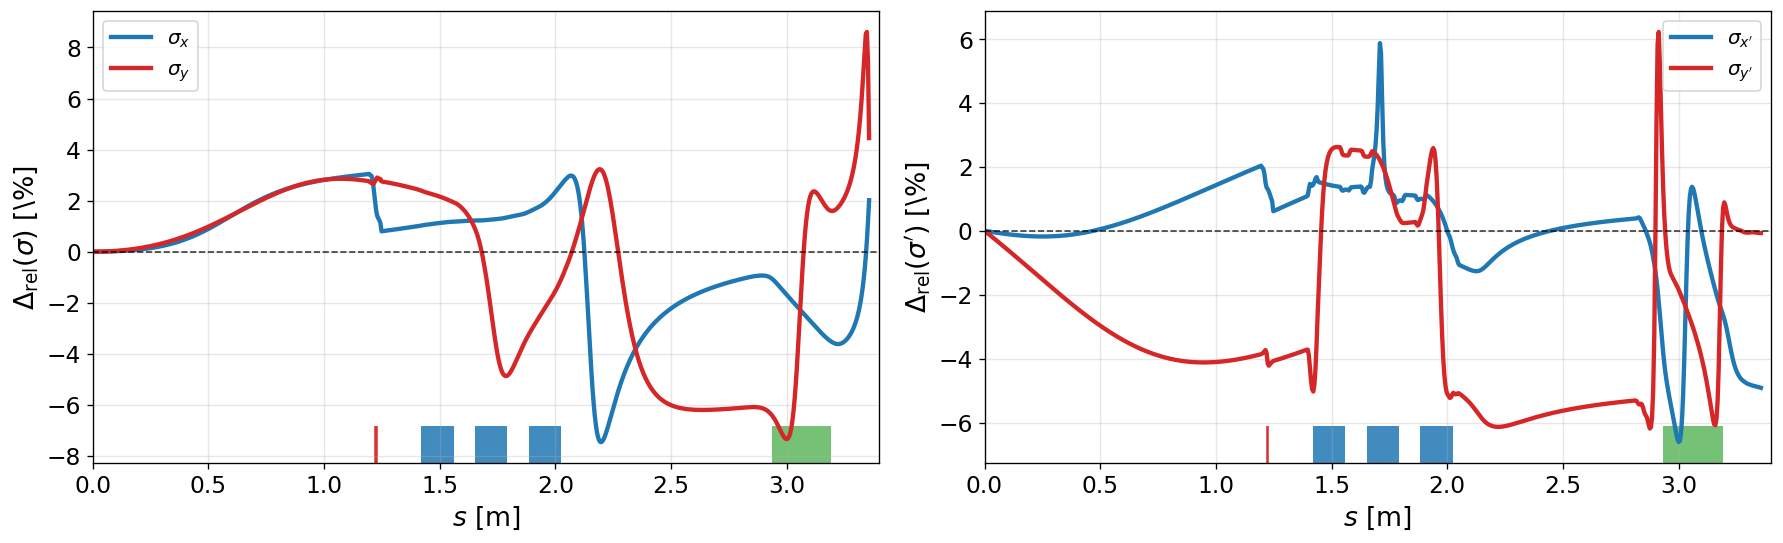

Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_OPAL_transverse_pairs.pdf
Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_OPAL_transverse_pairs.png


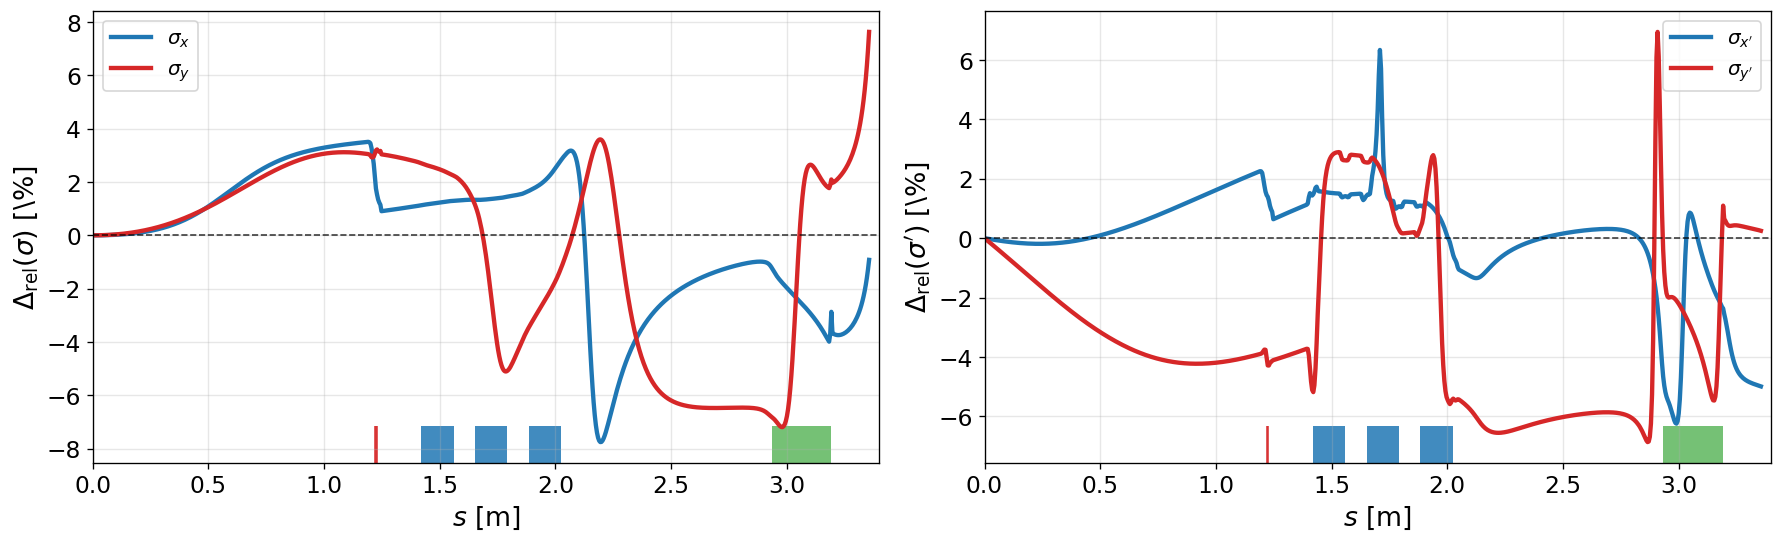

Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_RFTrack_Volume_transverse_pairs.pdf
Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_RFTrack_Volume_transverse_pairs.png


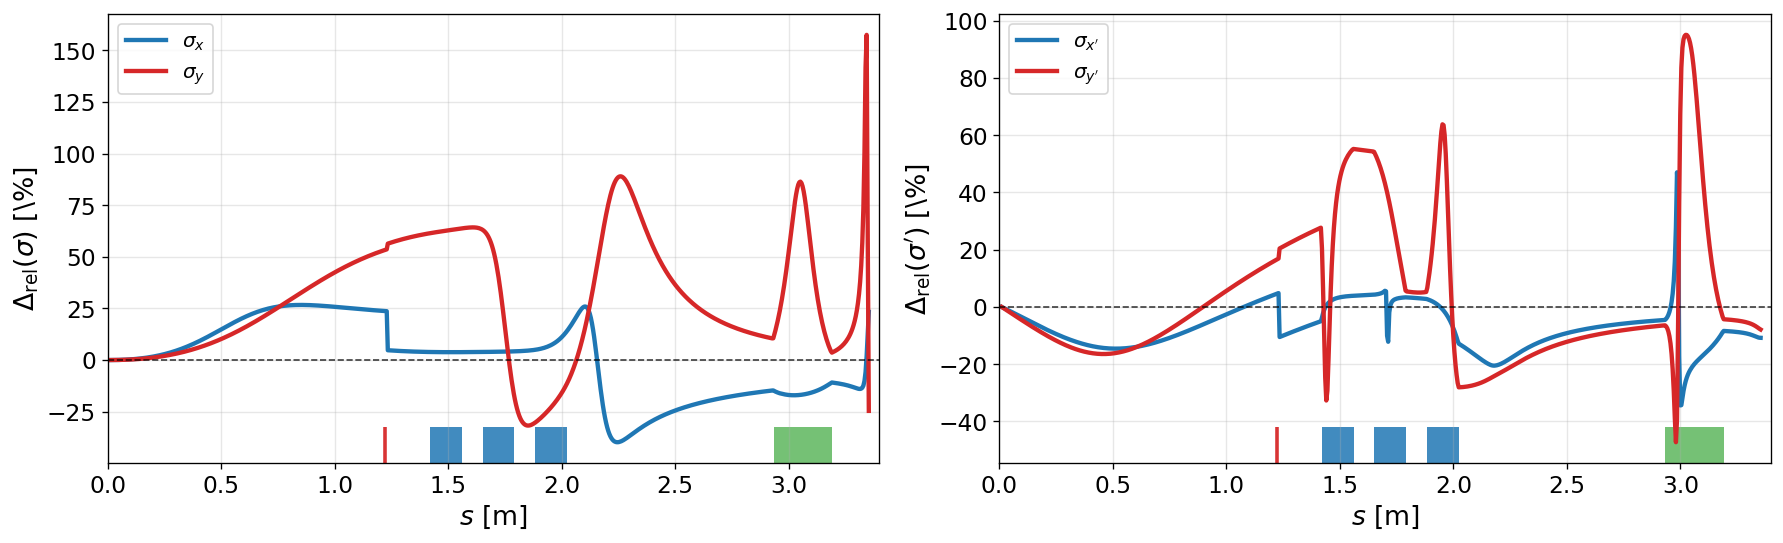

Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_TraceWin_transverse_pairs.pdf
Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_TraceWin_transverse_pairs.png


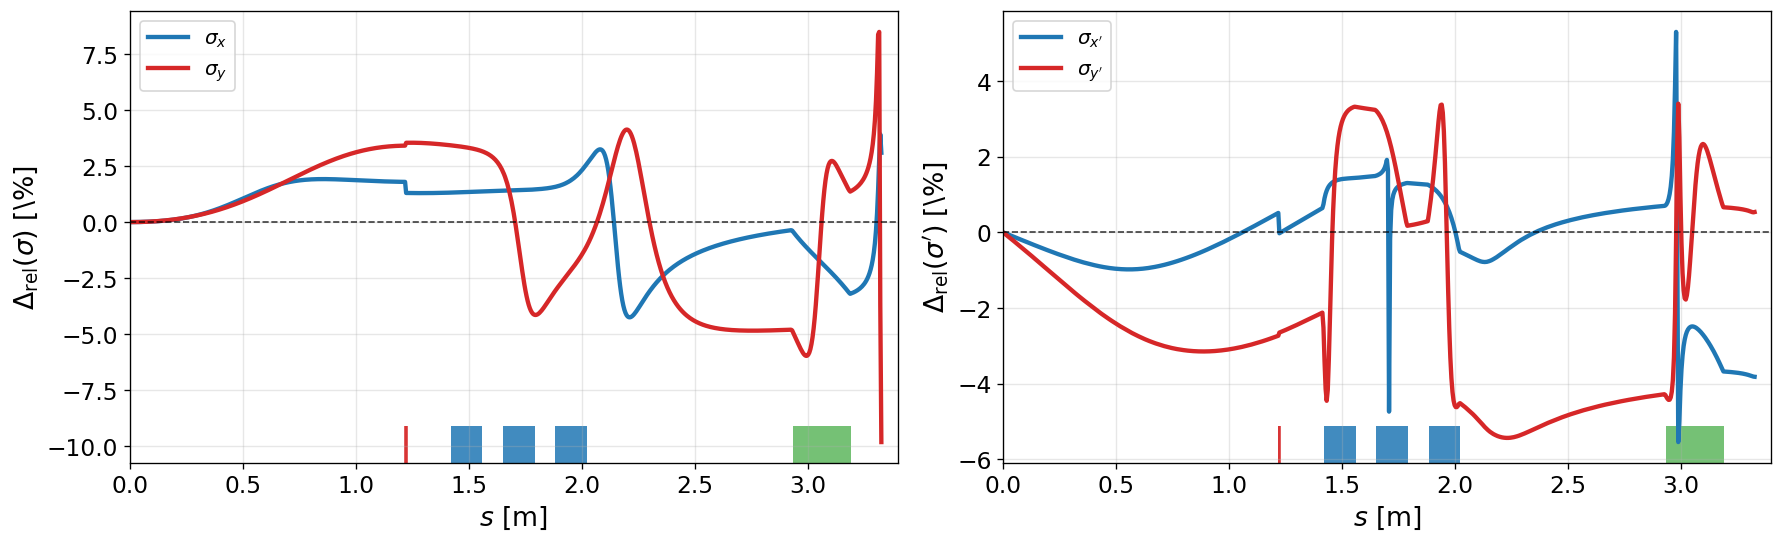

Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_TRAVEL_transverse_pairs.pdf
Figura guardada en: beam_plots/benchmark_sc_vs_no_sc/relative_change_percent/relative_change_percent_TRAVEL_transverse_pairs.png

Benchmark de cambio relativo porcentual terminado.


In [68]:
# ============================================================
# BENCHMARK MISMO CÓDIGO: CAMBIO RELATIVO [%] CON SC vs SIN SC
# ============================================================
# Uso:
#   1) En benchmark.ipynb, sin carga espacial:
#          MODE = "save_no_sc"
#
#   2) En benchmark_sc.ipynb, con carga espacial:
#          MODE = "compare_sc"
#
# Magnitud ploteada:
#   Delta_rel [%] = 100 * (con SC - sin SC) / sin SC
# ============================================================

from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display


# ============================================================
# MODO
# ============================================================

MODE = "compare_sc"   # cambia a "save_no_sc" en benchmark.ipynb sin SC


# ============================================================
# Configuración
# ============================================================

N_COMMON = 700

SNAPSHOT_DIR = Path("benchmark_snapshots")
SNAPSHOT_DIR.mkdir(parents=True, exist_ok=True)

NO_SC_FILE = SNAPSHOT_DIR / "benchmark_no_sc.pkl"

benchmark_outdir = Path("beam_plots") / "benchmark_sc_vs_no_sc" / "relative_change_percent"
benchmark_outdir.mkdir(parents=True, exist_ok=True)

DRAW_LATTICE = True

show_in_notebook = globals().get("show_in_notebook", True)

FIG_WIDTH_LOCAL = globals().get("FIG_WIDTH", 7.0)
FIG_HEIGHT_LOCAL = globals().get("FIG_HEIGHT", 4.0)

FONT_SIZE_LOCAL = 13
LABEL_SIZE_LOCAL = 16    # nombres de ejes
TICK_SIZE_LOCAL = 14     # números de los ejes
LEGEND_SIZE_LOCAL = 12
TITLE_SIZE_LOCAL = 14

# Solo se dibuja lattice en estas magnitudes
LATTICE_KEYS = {"sx", "sy", "sxp", "syp"}

plt.rcParams.update({
    "font.size": FONT_SIZE_LOCAL,
    "axes.labelsize": LABEL_SIZE_LOCAL,
    "xtick.labelsize": TICK_SIZE_LOCAL,
    "ytick.labelsize": TICK_SIZE_LOCAL,
    "legend.fontsize": LEGEND_SIZE_LOCAL,
    "axes.titlesize": TITLE_SIZE_LOCAL,
    "figure.titlesize": TITLE_SIZE_LOCAL,
})


# ============================================================
# Helpers generales
# ============================================================

def arr(x):
    return np.atleast_1d(np.asarray(x, dtype=float)).ravel()


def first_defined(*names):
    for name in names:
        if name in globals():
            return globals()[name]
    return None


def slug(text):
    return (
        str(text)
        .replace(" ", "_")
        .replace("-", "")
        .replace(".", "")
        .replace("/", "_")
        .replace("'", "")
        .replace("$", "")
        .replace("\\", "")
        .replace("{", "")
        .replace("}", "")
        .replace("%", "pct")
    )


def clean_curve(s, y):
    if s is None or y is None:
        return np.array([]), np.array([])

    s = arr(s)
    y = arr(y)

    if len(y) == 1 and len(s) > 1:
        y = np.full_like(s, y[0], dtype=float)

    if len(s) == 1 and len(y) > 1:
        s = np.full_like(y, s[0], dtype=float)

    n = min(len(s), len(y))
    s = s[:n]
    y = y[:n]

    mask = np.isfinite(s) & np.isfinite(y)
    s = s[mask]
    y = y[mask]

    if len(s) == 0:
        return s, y

    order = np.argsort(s)
    s = s[order]
    y = y[order]

    s_unique, idx = np.unique(s, return_index=True)
    y_unique = y[idx]

    return s_unique, y_unique


def transmission_to_percent(values, N0=15673, name=""):
    values = arr(values)
    finite = values[np.isfinite(values)]

    if len(finite) == 0:
        return values

    vmax = np.nanmax(finite)

    # Ya está en porcentaje
    if vmax <= 105:
        return values

    # Parece porcentaje x100
    if vmax <= 10500:
        print(f"{name}: transmisión parece % x100. Dividiendo entre 100.")
        return values / 100.0

    # Parece número de partículas
    if vmax <= 1.2 * N0:
        print(f"{name}: transmisión parece número de partículas. Convirtiendo a %.")
        return 100.0 * values / N0

    print(f"{name}: transmisión anómala, max = {vmax:.4g}. Convirtiendo respecto a N0.")
    return 100.0 * values / N0


def maybe_rad_to_mrad(values):
    """
    Si parece estar en rad, convierte a mrad.
    Si ya está en mrad, lo deja igual.
    """
    if values is None:
        return None

    values = arr(values)
    finite = values[np.isfinite(values)]

    if len(finite) == 0:
        return values

    med = np.nanmedian(np.abs(finite))

    if med < 1.0:
        return values * 1e3

    return values


def common_grid(curve_no_sc, curve_sc, n=N_COMMON):
    s0, y0 = clean_curve(curve_no_sc["s"], curve_no_sc["y"])
    s1, y1 = clean_curve(curve_sc["s"], curve_sc["y"])

    if len(s0) < 2 or len(s1) < 2:
        return None, None, None

    s_min = max(
        np.min(s0),
        np.min(s1),
        globals().get("s_min_plot", -np.inf)
    )

    s_max = min(
        np.max(s0),
        np.max(s1),
        globals().get("s_max_plot", np.inf)
    )

    if not np.isfinite(s_min) or not np.isfinite(s_max) or s_max <= s_min:
        return None, None, None

    s_common = np.linspace(s_min, s_max, n)

    y_no_sc = np.interp(s_common, s0, y0)
    y_sc = np.interp(s_common, s1, y1)

    return s_common, y_no_sc, y_sc


def relative_change_percent(y_sc, y_no_sc, eps=1e-15):
    """
    Cambio relativo en porcentaje:

        Delta_rel [%] = 100 * (SC - noSC) / noSC
    """
    y_sc = arr(y_sc)
    y_no_sc = arr(y_no_sc)

    out = np.full_like(y_sc, np.nan, dtype=float)

    mask = (
        np.isfinite(y_sc)
        & np.isfinite(y_no_sc)
        & (np.abs(y_no_sc) > eps)
    )

    out[mask] = 100.0 * (y_sc[mask] - y_no_sc[mask]) / y_no_sc[mask]

    return out


def plot_lattice_for_key(ax, key):
    """
    Dibuja lattice solo en magnitudes transversales.
    """
    if not DRAW_LATTICE:
        return

    if key not in LATTICE_KEYS:
        return

    if "plot_lattice" not in globals():
        return

    plot_lattice(
        ax,
        s_offset=0.0,
        height_frac=0.08,
        show_labels=False,
        show_legend=False,
    )


def style_axis(ax, key):
    ax.grid(True, alpha=0.3)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_SIZE_LOCAL
    )

    ax.xaxis.label.set_size(LABEL_SIZE_LOCAL)
    ax.yaxis.label.set_size(LABEL_SIZE_LOCAL)
    ax.title.set_size(TITLE_SIZE_LOCAL)

    if "xlim_plot" in globals():
        ax.set_xlim(xlim_plot)

    plot_lattice_for_key(ax, key)


# ============================================================
# Parámetros y estilos
# ============================================================

PARAMS = {
    "sx": {
        "label": r"$\sigma_x$",
        "ylabel": r"$\Delta_\mathrm{rel}(\sigma_x)$ [\%]",
        "unit": "mm",
        "name": "sigma_x",
    },
    "sy": {
        "label": r"$\sigma_y$",
        "ylabel": r"$\Delta_\mathrm{rel}(\sigma_y)$ [\%]",
        "unit": "mm",
        "name": "sigma_y",
    },
    "sxp": {
        "label": r"$\sigma_{x'}$",
        "ylabel": r"$\Delta_\mathrm{rel}(\sigma_{x'})$ [\%]",
        "unit": "mrad",
        "name": "sigma_xp",
    },
    "syp": {
        "label": r"$\sigma_{y'}$",
        "ylabel": r"$\Delta_\mathrm{rel}(\sigma_{y'})$ [\%]",
        "unit": "mrad",
        "name": "sigma_yp",
    },
    "E": {
        "label": r"$E$",
        "ylabel": r"$\Delta_\mathrm{rel}(E)$ [\%]",
        "unit": "MeV",
        "name": "energy",
    },
    "P": {
        "label": r"$P$",
        "ylabel": r"$\Delta_\mathrm{rel}(P)$ [\%]",
        "unit": "MeV/c",
        "name": "momentum",
    },
    "T": {
        "label": r"$T$",
        "ylabel": r"$\Delta_\mathrm{rel}(T)$ [\%]",
        "unit": "%",
        "name": "transmission",
    },
}

# Figuras finales:
#   - panel 1: sigma_x y sigma_y juntos
#   - panel 2: sigma_xp y sigma_yp juntos
TRANSVERSE_PAIR_GROUPS = {
    "xy": ["sx", "sy"],
    "xpyp": ["sxp", "syp"],
}

PAIR_TITLES = {
    "xy": r"Tamaños transversales",
    "xpyp": r"Divergencias transversales",
}

PAIR_YLABELS = {
    "xy": r"$\Delta_\mathrm{rel}(\sigma)$ [\%]",
    "xpyp": r"$\Delta_\mathrm{rel}(\sigma')$ [\%]",
}

PAIR_FILENAMES = {
    "xy": "sigma_xy",
    "xpyp": "sigma_xpyp",
}


# ============================================================
# Colores por plano
# ============================================================

lab_opal = "OPAL"
lab_rfv = "RF-Track Volume"
lab_tw = "TraceWin"
lab_travel = "TRAVEL"

c_x = "tab:blue"
c_y = "tab:red"


CODE_LABELS = {
    "OPAL": lab_opal,
    "RF-Track Volume": lab_rfv,
    "TraceWin": lab_tw,
    "TRAVEL": lab_travel,
}


def plane_style_for_code(code, key):
    """
    En todas las figuras:
      - sigma_x / sigma_xp en azul.
      - sigma_y / sigma_yp en rojo.
    """

    if key in {"sx", "sxp"}:
        return {
            "color": c_x,
            "linestyle": "-",
            "lw": 2.6,
        }

    if key in {"sy", "syp"}:
        return {
            "color": c_y,
            "linestyle": "-",
            "lw": 2.6,
        }

    return {
        "color": "black",
        "linestyle": "-",
        "lw": 2.4,
    }

# ============================================================
# Añadir código al diccionario
# ============================================================

def add_code(codes, name, curves):
    clean = {}

    for key, curve in curves.items():
        s, y = clean_curve(curve["s"], curve["y"])

        if len(s) >= 2:
            clean[key] = {
                "s": s,
                "y": y,
            }

    if len(clean) > 0:
        codes[name] = clean


# ============================================================
# Recoger datos del notebook actual
# ============================================================

def collect_current_state():
    codes = {}

    # --------------------------------------------------------
    # OPAL
    # --------------------------------------------------------
    if "s_opal" in globals():
        T_opal_here = first_defined("T_opal")

        if T_opal_here is None and "N_opal" in globals():
            T_opal_here = transmission_to_percent(N_opal, name="OPAL")

        add_code(
            codes,
            "OPAL",
            {
                "sx":  {"s": s_opal, "y": rms_x_opal},
                "sy":  {"s": s_opal, "y": rms_y_opal},
                "sxp": {"s": s_opal, "y": sigma_px_opal},
                "syp": {"s": s_opal, "y": sigma_py_opal},
                "E":   {"s": s_opal, "y": E_opal},
                "P":   {"s": s_opal, "y": P_opal},
                "T":   {"s": s_opal, "y": T_opal_here},
            }
        )

    # --------------------------------------------------------
    # RF-Track Volume
    # --------------------------------------------------------
    if "s_rf_vol" in globals():
        T_rf_vol_here = first_defined("T_rf_vol")

        if T_rf_vol_here is None and "N_rf_vol" in globals():
            N_arr = arr(N_rf_vol)

            if len(N_arr) > 0 and np.isfinite(N_arr[0]) and N_arr[0] != 0:
                T_rf_vol_here = 100.0 * N_arr / N_arr[0]
            else:
                T_rf_vol_here = transmission_to_percent(N_rf_vol, name="RF-Track Volume")

        add_code(
            codes,
            "RF-Track Volume",
            {
                "sx":  {"s": s_rf_vol, "y": rms_x_rf_vol},
                "sy":  {"s": s_rf_vol, "y": rms_y_rf_vol},
                "sxp": {"s": s_rf_vol, "y": sigma_xp_rf_vol},
                "syp": {"s": s_rf_vol, "y": sigma_yp_rf_vol},
                "E":   {"s": s_rf_vol, "y": E_rf_vol},
                "P":   {"s": s_rf_vol, "y": P_rf_vol},
                "T":   {"s": s_rf_vol, "y": T_rf_vol_here},
            }
        )

    # --------------------------------------------------------
    # TraceWin
    # --------------------------------------------------------
    tw_sx = first_defined("s_tw_x_draw", "s_tracewin_x")
    tw_sy = first_defined("s_tw_y_draw", "s_tracewin_y")
    tw_env = first_defined("s_tw_env_draw", "s_tracewin_envelope")
    tw_sN = first_defined("s_tw_N_draw", "s_tracewin_N")

    tw_x = first_defined("tracewin_sigma_x_plot", "rms_x_tracewin")
    tw_y = first_defined("tracewin_sigma_y_plot", "rms_y_tracewin")

    tw_xp = first_defined("tracewin_sigma_xp_plot", "sigma_xp_tracewin")
    tw_yp = first_defined("tracewin_sigma_yp_plot", "sigma_yp_tracewin")

    tw_xp = maybe_rad_to_mrad(tw_xp)
    tw_yp = maybe_rad_to_mrad(tw_yp)

    tw_E = first_defined("tracewin_E_plot", "E_tracewin")
    tw_P = first_defined("tracewin_P_plot", "P_tracewin")

    tw_T = first_defined("tracewin_T_plot")

    if tw_T is None and "N_tracewin" in globals():
        tw_T = transmission_to_percent(N_tracewin, name="TraceWin")

    if tw_sx is not None:
        add_code(
            codes,
            "TraceWin",
            {
                "sx":  {"s": tw_sx,  "y": tw_x},
                "sy":  {"s": tw_sy,  "y": tw_y},
                "sxp": {"s": tw_env, "y": tw_xp},
                "syp": {"s": tw_env, "y": tw_yp},
                "E":   {"s": tw_env, "y": tw_E},
                "P":   {"s": tw_env, "y": tw_P},
                "T":   {"s": tw_sN,  "y": tw_T},
            }
        )

    # --------------------------------------------------------
    # TRAVEL
    # --------------------------------------------------------
    if "s_travel" in globals():
        s_travel_T = first_defined("s_travel_N")

        if s_travel_T is None:
            if (
                "travel_avg" in globals()
                and np.asarray(travel_avg).ndim == 2
                and travel_avg.shape[1] > 2
            ):
                s_travel_T = travel_avg[:, 2]
            else:
                s_travel_T = s_travel

        T_travel_here = first_defined("T_travel")

        if T_travel_here is None and "N_travel" in globals():
            T_travel_here = transmission_to_percent(N_travel, name="TRAVEL")

        E_travel_here = first_defined("E_travel_plot", "E_travel")
        P_travel_here = first_defined("P_travel_plot", "P_travel")

        add_code(
            codes,
            "TRAVEL",
            {
                "sx":  {"s": s_travel,   "y": rms_x_travel},
                "sy":  {"s": s_travel,   "y": rms_y_travel},
                "sxp": {"s": s_travel,   "y": sigma_xp_travel},
                "syp": {"s": s_travel,   "y": sigma_yp_travel},
                "E":   {"s": s_travel,   "y": E_travel_here},
                "P":   {"s": s_travel,   "y": P_travel_here},
                "T":   {"s": s_travel_T, "y": T_travel_here},
            }
        )

    return codes


# ============================================================
# Guardar / cargar snapshot
# ============================================================

def save_snapshot(codes, path):
    with open(path, "wb") as f:
        pickle.dump(codes, f)

    print(f"Snapshot guardado en: {path}")
    print("Códigos guardados:")

    for code, data in codes.items():
        print(f"  - {code}: {list(data.keys())}")


def load_snapshot(path):
    with open(path, "rb") as f:
        codes = pickle.load(f)

    print(f"Snapshot cargado desde: {path}")
    print("Códigos cargados:")

    for code, data in codes.items():
        print(f"  - {code}: {list(data.keys())}")

    return codes


# ============================================================
# Plot de cambio relativo porcentual
# ============================================================

def plot_relative_change_percent_transverse_pairs(code, codes_no_sc, codes_sc):
    """
    Genera una figura por código con dos paneles:

        1) sigma_x y sigma_y juntos.
        2) sigma_xp y sigma_yp juntos.

    Cada panel contiene dos curvas: una para el plano X y otra para el plano Y.
    Se guardan PDF y PNG.
    """
    pair_names = ["xy", "xpyp"]

    # Comprueba si hay al menos una curva válida en alguno de los dos paneles
    has_any_valid_curve = False

    for pair_name in pair_names:
        for key in TRANSVERSE_PAIR_GROUPS[pair_name]:
            if key in codes_no_sc[code] and key in codes_sc[code]:
                has_any_valid_curve = True
                break

    if not has_any_valid_curve:
        return

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(2.15 * FIG_WIDTH_LOCAL, 1.18 * FIG_HEIGHT_LOCAL),
        sharex=True
    )

    for ax, pair_name in zip(axs, pair_names):
        keys = TRANSVERSE_PAIR_GROUPS[pair_name]
        plotted = False

        for key in keys:
            if key not in codes_no_sc[code] or key not in codes_sc[code]:
                continue

            meta = PARAMS[key]

            s, y_no_sc, y_sc = common_grid(
                codes_no_sc[code][key],
                codes_sc[code][key],
                n=N_COMMON
            )

            if s is None:
                continue

            d_rel_percent = relative_change_percent(y_sc, y_no_sc)
            st = plane_style_for_code(code, key)

            code_label = CODE_LABELS.get(code, code)

            ax.plot(
                s,
                d_rel_percent,
                color=st.get("color", "black"),
                linestyle=st.get("linestyle", "-"),
                linewidth=st.get("lw", 2.4),
                label=rf"{meta['label']}"
            )

            plotted = True

        ax.axhline(
            0.0,
            color="black",
            linestyle="--",
            linewidth=1.0,
            alpha=0.75
        )

        ax.set_ylabel(PAIR_YLABELS[pair_name])
        ax.set_xlabel(r"$s$ [m]")

        # Dibuja lattice porque ambos paneles son magnitudes transversales.
        # Se usa la primera key del grupo para activar la lógica existente.
        style_axis(ax, keys[0])

        if plotted:
            ax.legend(
                fontsize=LEGEND_SIZE_LOCAL,
                frameon=True,
                loc="best"
            )
        else:
            ax.text(
                0.5,
                0.5,
                "Sin datos",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

    fig.tight_layout()

    filename_base = benchmark_outdir / f"relative_change_percent_{slug(code)}_transverse_pairs"
    filename_pdf = filename_base.with_suffix(".pdf")
    filename_png = filename_base.with_suffix(".png")

    fig.savefig(filename_pdf, dpi=300, bbox_inches="tight")
    fig.savefig(filename_png, dpi=300, bbox_inches="tight")

    if show_in_notebook:
        display(fig)

    plt.close(fig)

    print(f"Figura guardada en: {filename_pdf}")
    print(f"Figura guardada en: {filename_png}")


# ============================================================
# Ejecución principal
# ============================================================

if MODE == "save_no_sc":

    codes_no_sc = collect_current_state()

    if len(codes_no_sc) == 0:
        raise RuntimeError("No se ha detectado ningún código cargado en el notebook sin SC.")

    save_snapshot(codes_no_sc, NO_SC_FILE)


elif MODE == "compare_sc":

    if not NO_SC_FILE.exists():
        raise FileNotFoundError(
            f"No existe {NO_SC_FILE}. "
            "Primero ejecuta esta celda en el notebook sin SC con MODE = 'save_no_sc'."
        )

    codes_no_sc = load_snapshot(NO_SC_FILE)
    codes_sc = collect_current_state()

    if len(codes_sc) == 0:
        raise RuntimeError("No se ha detectado ningún código cargado en el notebook con SC.")

    common_codes = [
        code for code in codes_no_sc
        if code in codes_sc
    ]

    print("\nCódigos comparados sin SC vs con SC:")

    for code in common_codes:
        print(f"  - {code}")

    rows = []

    for code in common_codes:
        common_params = [
            key for key in PARAMS
            if key in codes_no_sc[code] and key in codes_sc[code]
        ]

        for key in common_params:
            meta = PARAMS[key]

            s, y_no_sc, y_sc = common_grid(
                codes_no_sc[code][key],
                codes_sc[code][key],
                n=N_COMMON
            )

            if s is None:
                continue

            d_abs = y_sc - y_no_sc
            d_rel_percent = relative_change_percent(y_sc, y_no_sc)

            rows.append({
                "Code": code,
                "Quantity": meta["name"],
                "Unit": meta["unit"],
                "s min [m]": s[0],
                "s max [m]": s[-1],
                "Mean |Delta_rel| [%]": np.nanmean(np.abs(d_rel_percent)),
                "Max |Delta_rel| [%]": np.nanmax(np.abs(d_rel_percent)),
                "Final Delta_rel [%]": d_rel_percent[-1],
                "Final Delta_abs": d_abs[-1],
                "Final sin SC": y_no_sc[-1],
                "Final con SC": y_sc[-1],
            })

    relative_summary = pd.DataFrame(rows)

    summary_csv = benchmark_outdir / "relative_change_percent_summary.csv"
    summary_tex = benchmark_outdir / "relative_change_percent_summary.tex"

    relative_summary.to_csv(summary_csv, index=False)

    relative_summary_tex = relative_summary.copy()

    for col in [
        "s min [m]",
        "s max [m]",
        "Mean |Delta_rel| [%]",
        "Max |Delta_rel| [%]",
        "Final Delta_rel [%]",
        "Final Delta_abs",
        "Final sin SC",
        "Final con SC",
    ]:
        relative_summary_tex[col] = relative_summary_tex[col].map(
            lambda x: f"{x:.4g}" if np.isfinite(x) else "nan"
        )

    relative_summary_tex.to_latex(
        summary_tex,
        index=False,
        escape=False
    )

    display(relative_summary)

    print(f"\nTabla CSV guardada en: {summary_csv}")
    print(f"Tabla LaTeX guardada en: {summary_tex}")

    for code in common_codes:
        plot_relative_change_percent_transverse_pairs(
            code,
            codes_no_sc,
            codes_sc
        )

    print("\nBenchmark de cambio relativo porcentual terminado.")


else:
    raise ValueError("MODE debe ser 'save_no_sc' o 'compare_sc'.")